## Exploratory Data Analysis (EDA)

### 1.0 Initial Data Understanding

#### 1.1 Load Datasets

In [1]:
import os
import pandas as pd 
from tabulate import tabulate

file_path = "diabetes_binary_health_indicators.csv"

if os.path.isfile(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    
    print("\nFirst five rows of the dataset:")
    print(tabulate(df.head(), headers='keys', tablefmt='pretty', showindex=False))
else:
    print(f"Error: The file '{file_path}' was not found!")


Dataset loaded successfully!

First five rows of the dataset:
+-----------------+--------+----------+-----------+-----+--------+--------+----------------------+--------------+--------+---------+-------------------+---------------+-----------+---------+----------+----------+----------+-----+-----+-----------+--------+
| Diabetes_binary | HighBP | HighChol | CholCheck | BMI | Smoker | Stroke | HeartDiseaseorAttack | PhysActivity | Fruits | Veggies | HvyAlcoholConsump | AnyHealthcare | NoDocCost | GenHlth | MentHlth | PhysHlth | DiffWalk | Sex | Age | Education | Income |
+-----------------+--------+----------+-----------+-----+--------+--------+----------------------+--------------+--------+---------+-------------------+---------------+-----------+---------+----------+----------+----------+-----+-----+-----------+--------+
|        1        |   0    |    1     |     1     | 15  |   1    |   0    |          0           |      0       |   1    |    1    |         0         |       1       

#### 1.2 Observations

In [2]:
# (Rows, Columns)
print("(Rows, Columns)") 
print(df.shape , "\n") 

# View the data types and missing values
print(df.info(), "\n")  

# check columns
print("[Columns]") 
print(df.columns, "\n") 

(Rows, Columns)
(236378, 22) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       236378 non-null  int64
 1   HighBP                236378 non-null  int64
 2   HighChol              236378 non-null  int64
 3   CholCheck             236378 non-null  int64
 4   BMI                   236378 non-null  int64
 5   Smoker                236378 non-null  int64
 6   Stroke                236378 non-null  int64
 7   HeartDiseaseorAttack  236378 non-null  int64
 8   PhysActivity          236378 non-null  int64
 9   Fruits                236378 non-null  int64
 10  Veggies               236378 non-null  int64
 11  HvyAlcoholConsump     236378 non-null  int64
 12  AnyHealthcare         236378 non-null  int64
 13  NoDocCost             236378 non-null  int64
 14  GenHlth               236378 non-null  int64
 15  Men

#### 1.3 Overview of the range 

In [3]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,...,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000
mean,0.294414,0.418558,0.402059,0.963347,28.953579,0.411997,0.038900,0.086548,0.779231,0.621259,...,0.962573,0.063737,2.480717,3.937710,3.751297,0.244113,0.477824,7.863930,5.139099,6.927451
std,0.455780,0.493324,0.490315,0.187909,6.552055,0.492196,0.193356,0.281172,0.414766,0.485074,...,0.189807,0.244284,1.029134,7.886506,8.245907,0.429561,0.499509,3.236997,0.946185,2.375450
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,28.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,1.000000,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,4.000000,2.000000,0.000000,1.000000,10.000000,6.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,11.000000


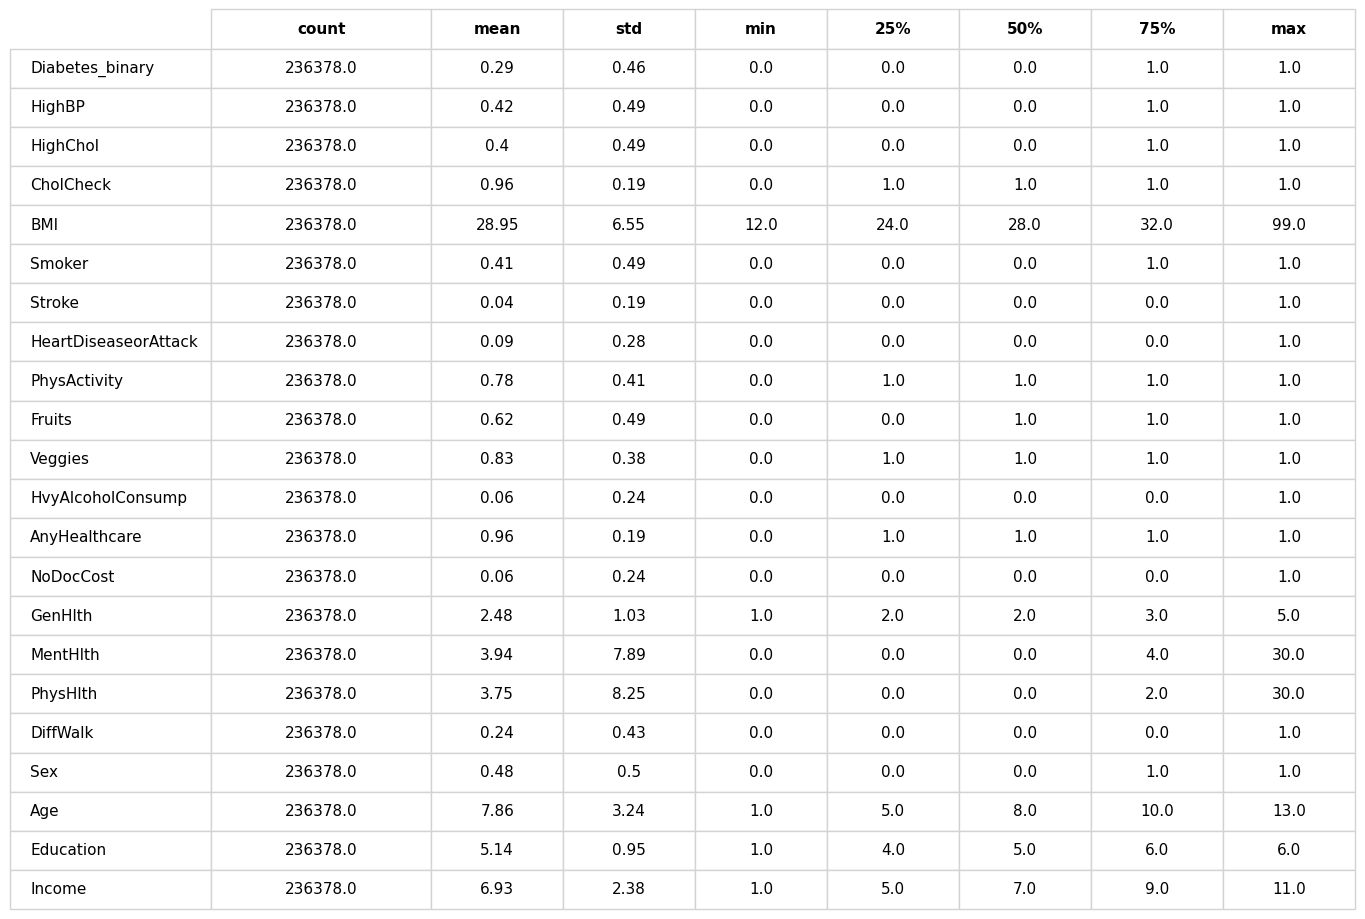

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

summary = df.describe().transpose()

# Convert count to integers
summary['count'] = summary['count'].astype(int)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

table = ax.table(cellText=summary.round(2).values,
                colLabels=summary.columns,
                rowLabels=summary.index,
                cellLoc='center',
                loc='center',
                colWidths=[0.20] + [0.12]*7) 

# Style adjustments
table.auto_set_font_size(False)
table.set_fontsize(11)

# Make header row bold
for (row, col), cell in table.get_celld().items():
    if row == 0: 
        cell.set_text_props(weight='bold')
    cell.set_height(0.06)  
    cell.set_edgecolor('lightgray') 

# Adjust layout
plt.tight_layout(pad=2.0) 
plt.show()

#### 1.4 View Categorical Variables

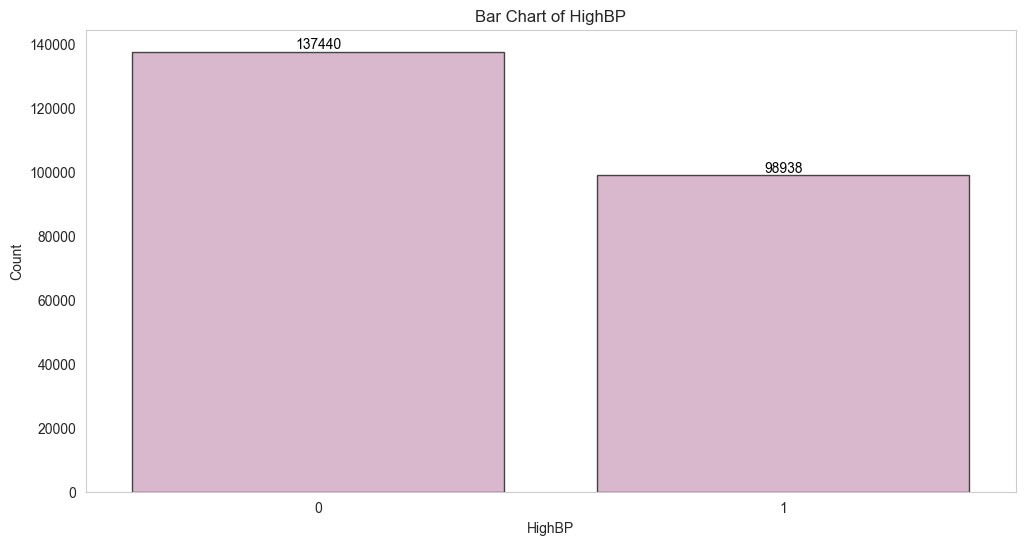

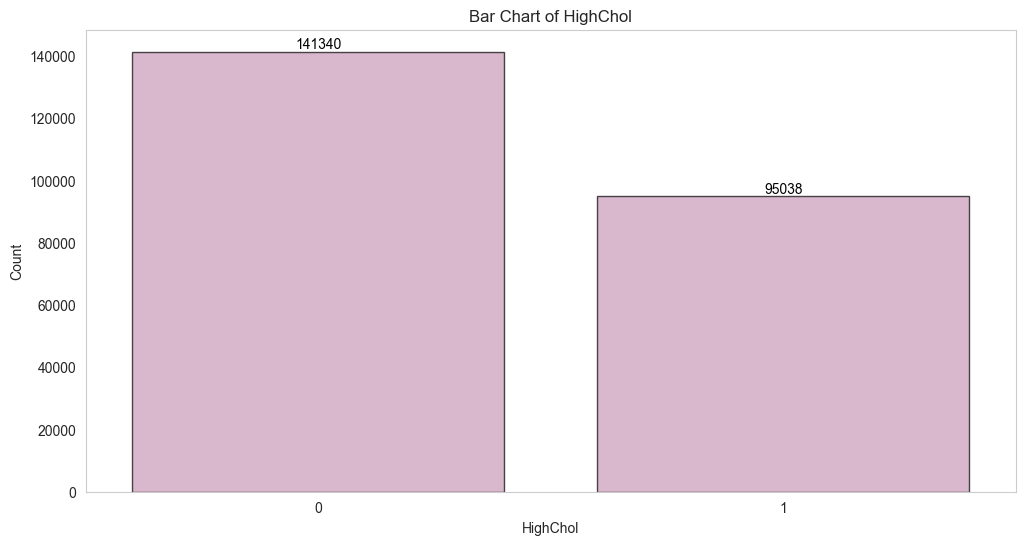

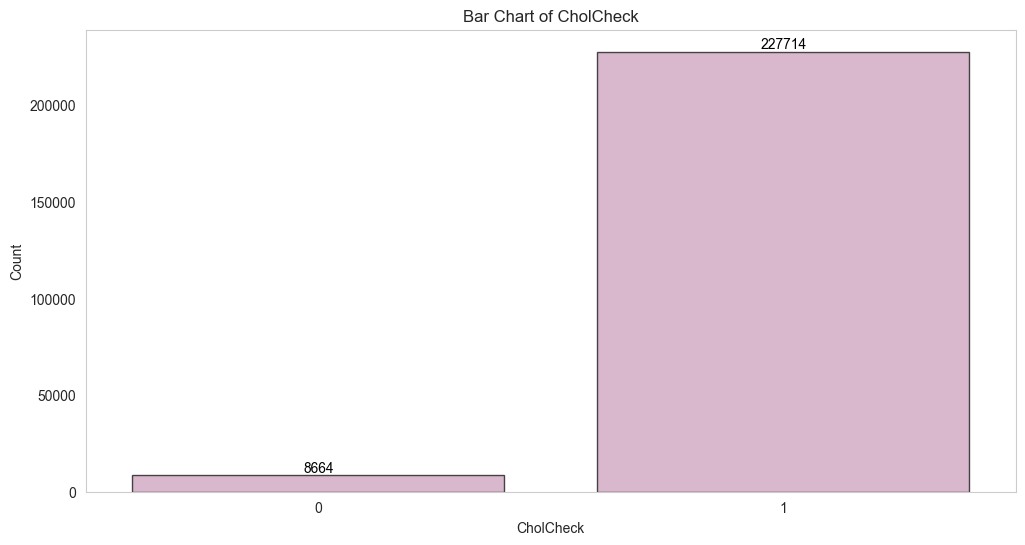

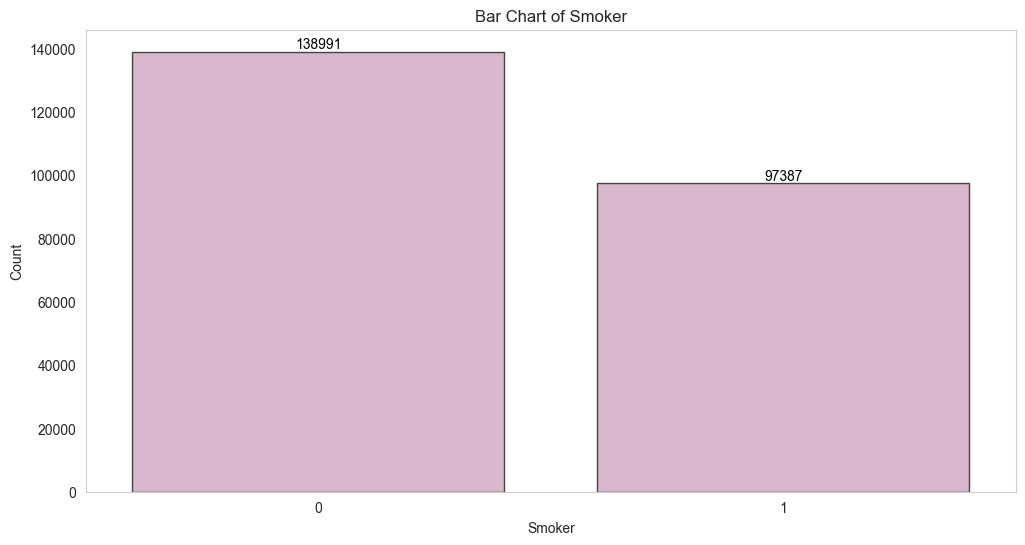

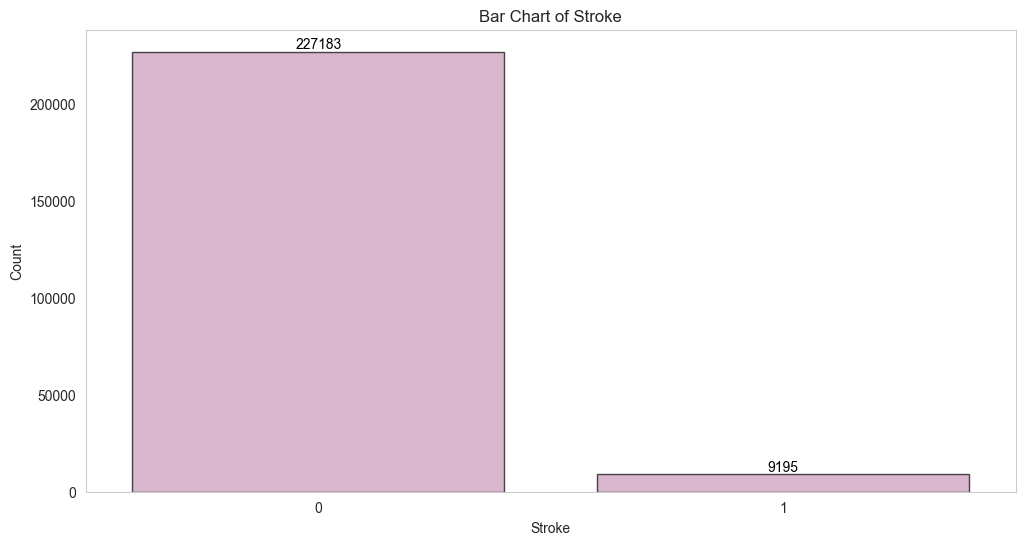

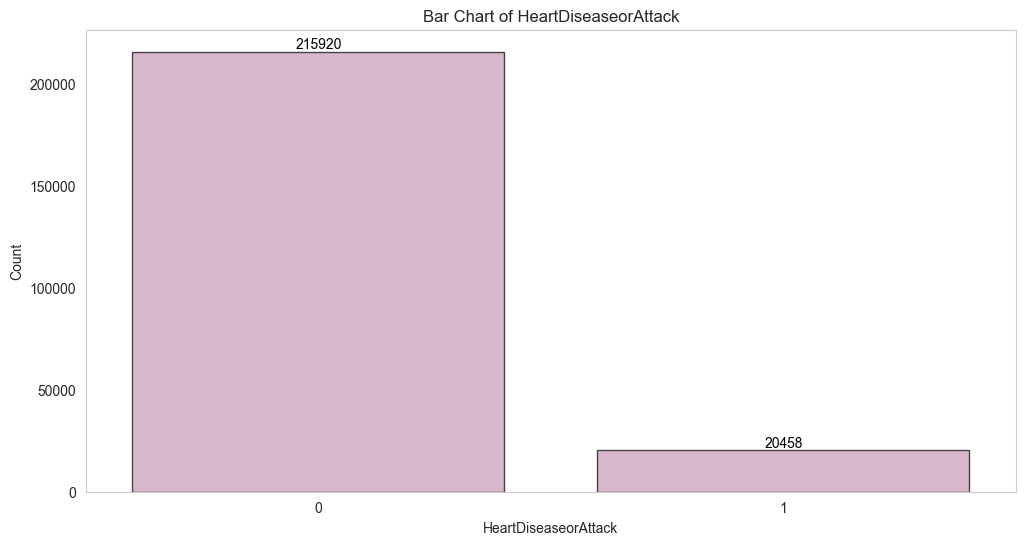

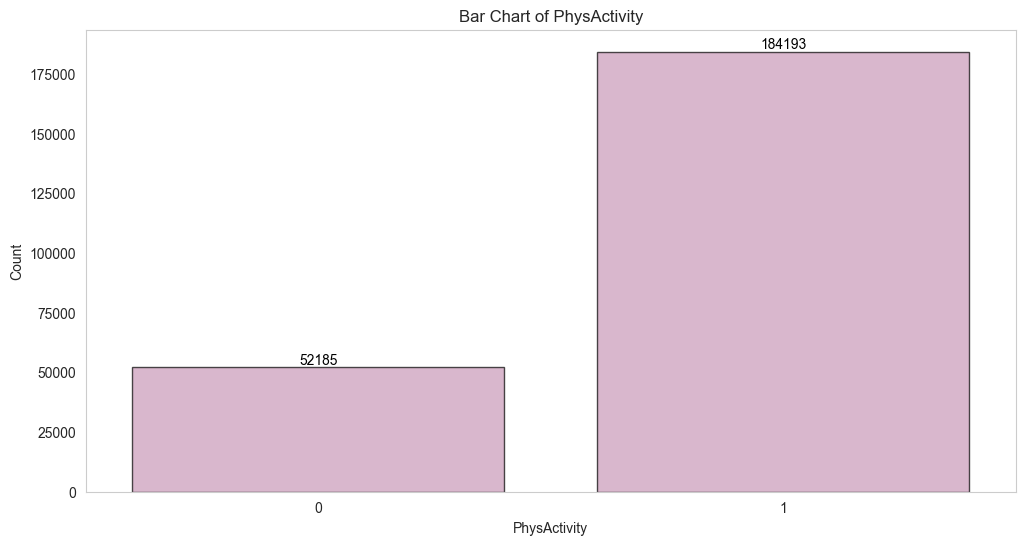

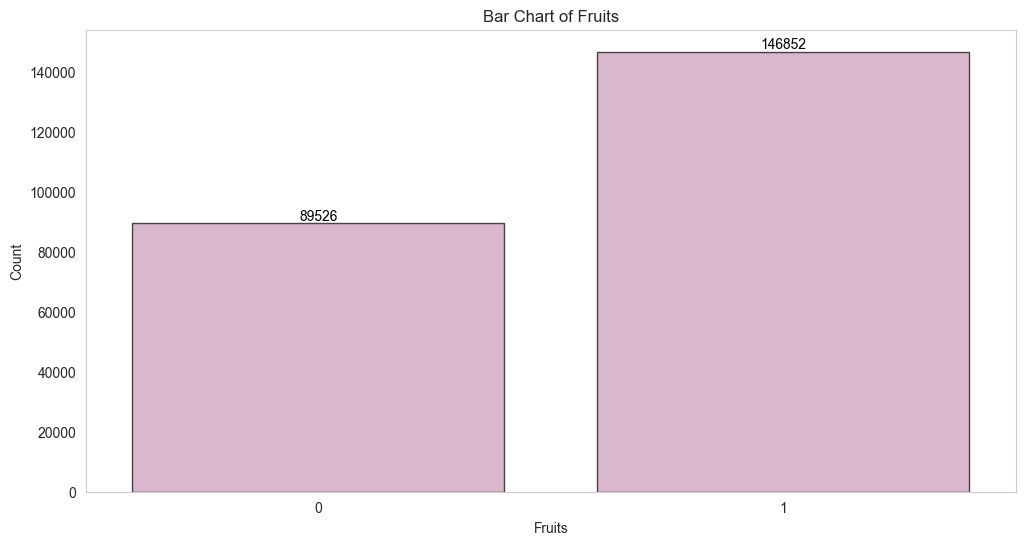

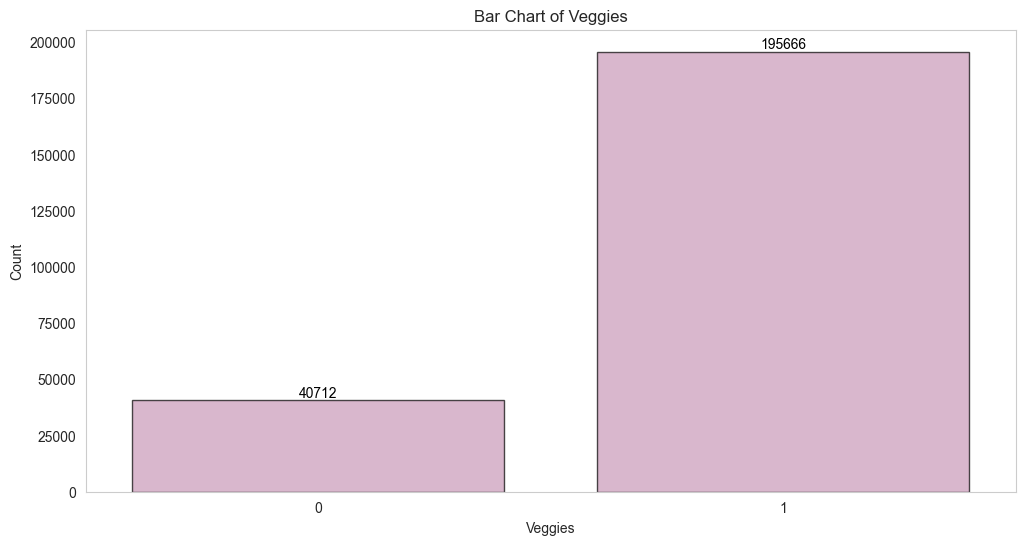

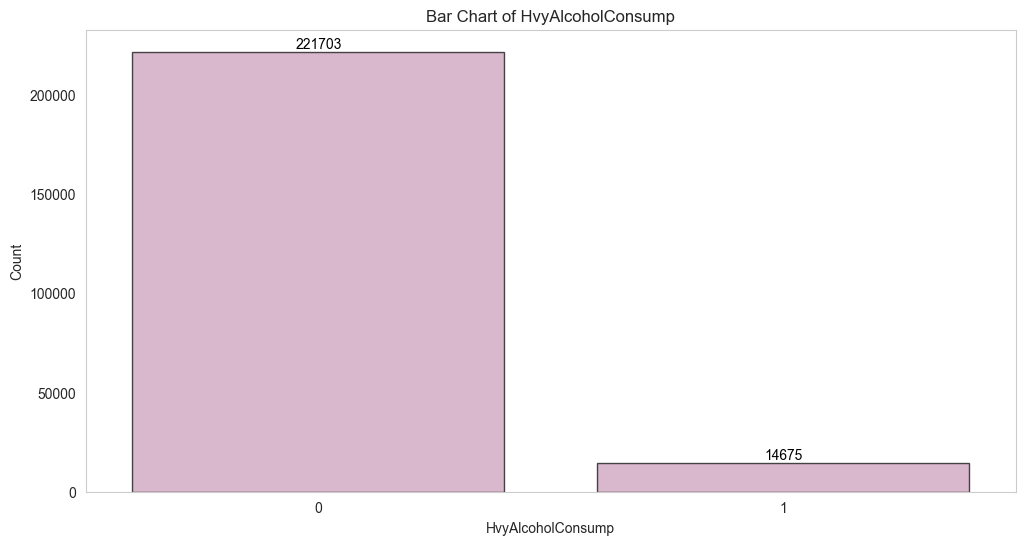

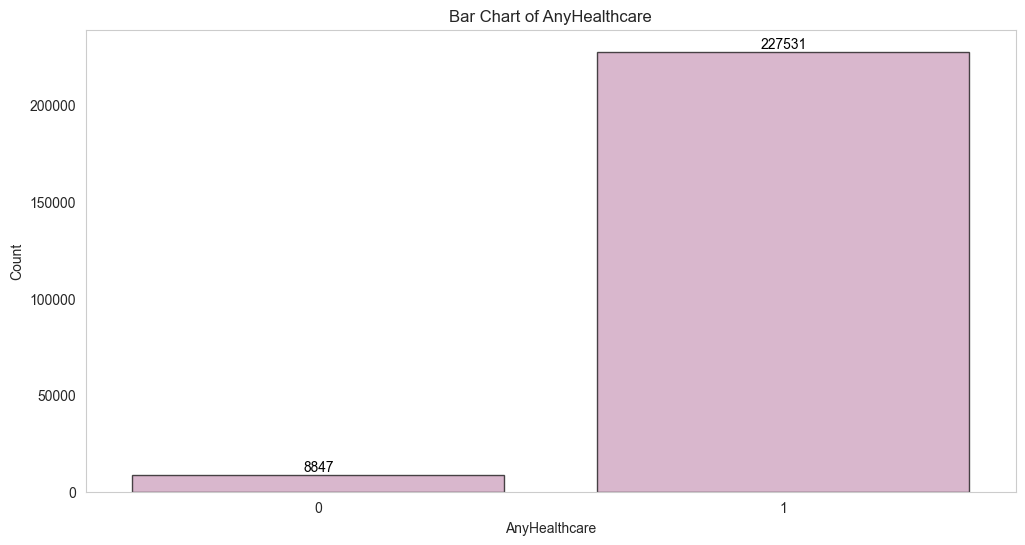

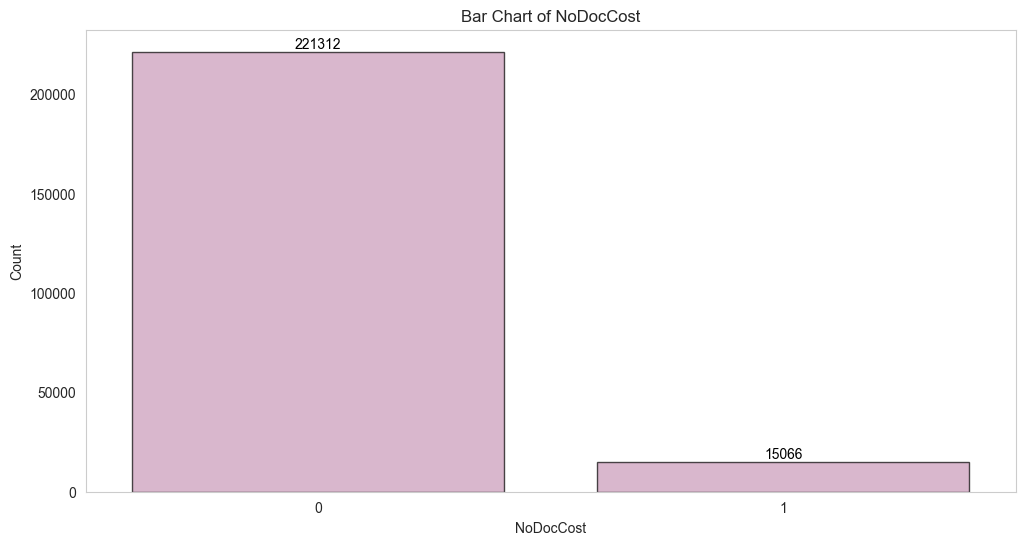

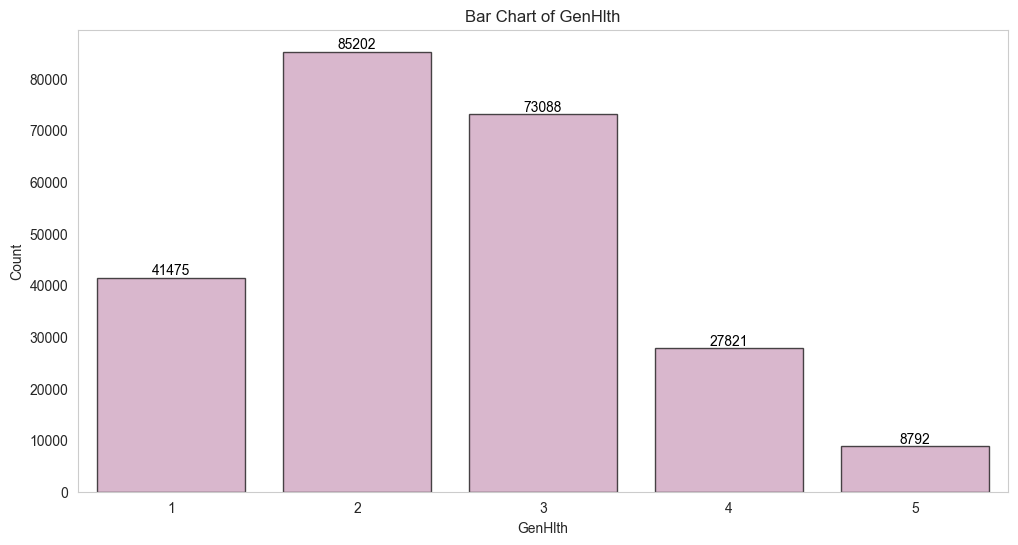

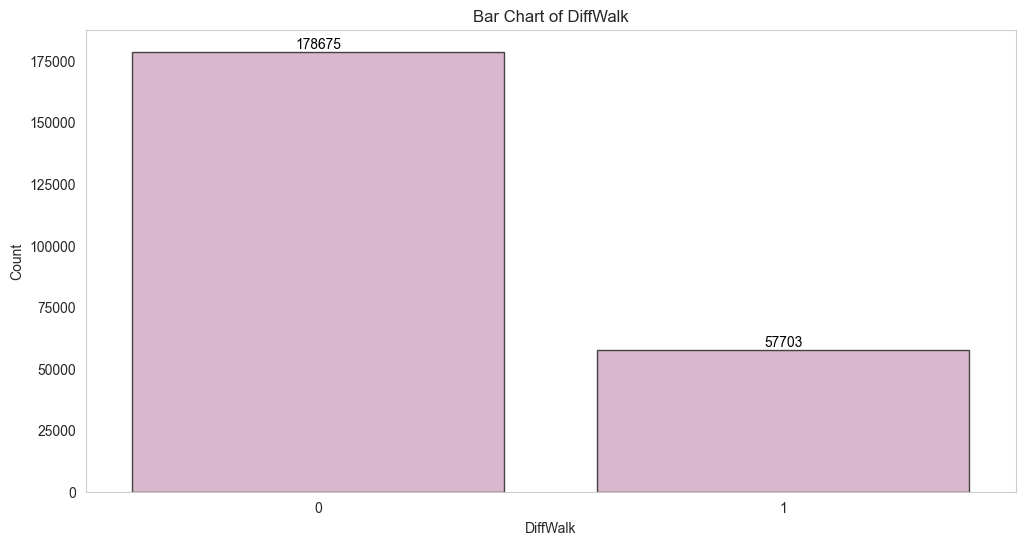

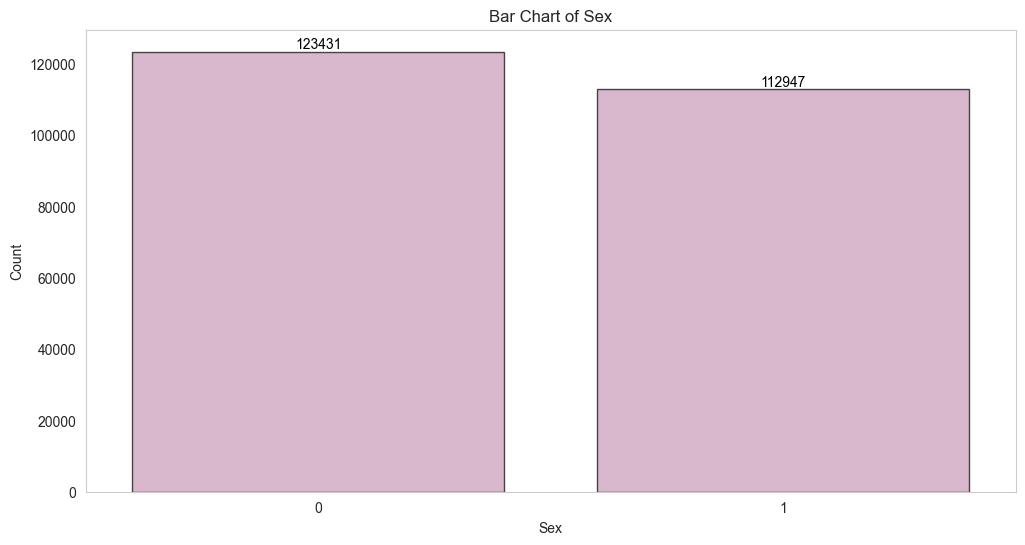

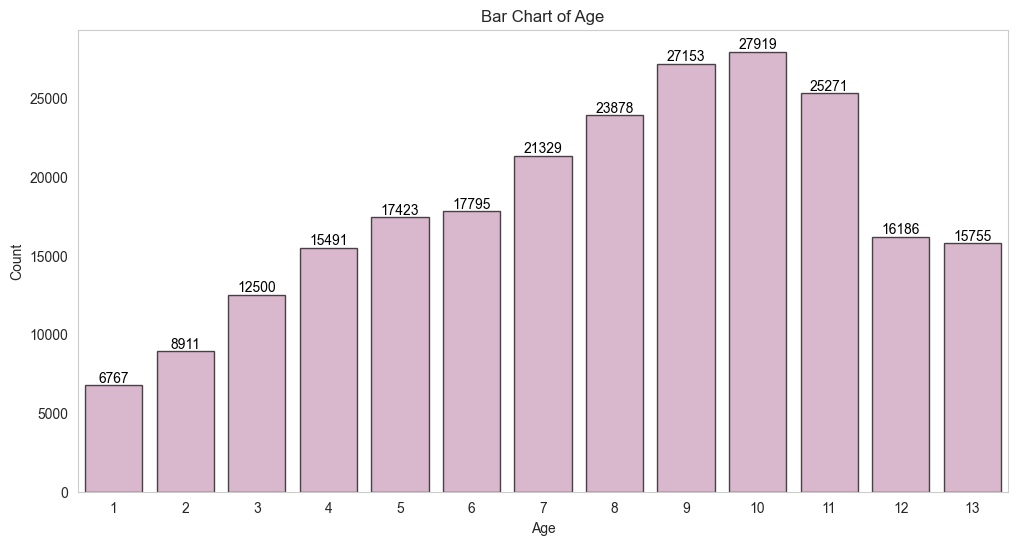

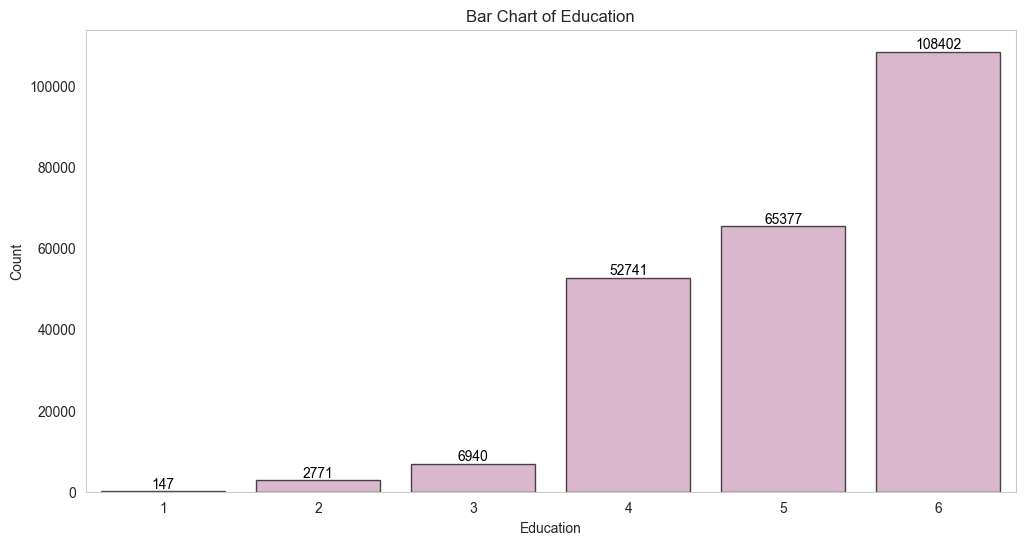

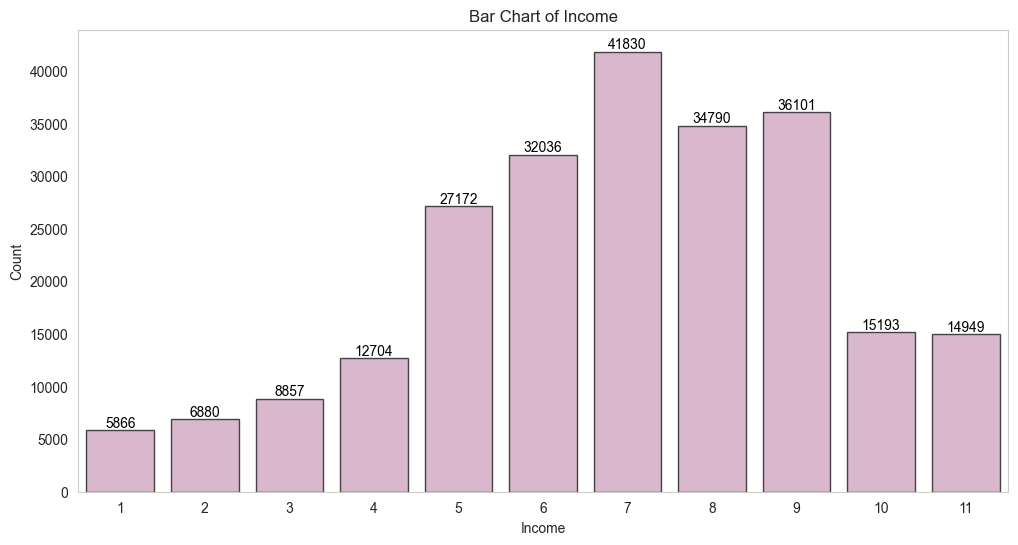

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the categorical columns
categorical_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 
    'AnyHealthcare', 'NoDocCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
]

sns.set_style("whitegrid")

# Loop through each categorical column and create a countplot
for col in categorical_cols:
    plt.figure(figsize=(12, 6))  
    ax = sns.countplot(data=df, x=col, edgecolor="black", alpha=0.7, color="#D291BC")
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(False)  
    plt.xticks(rotation=0, ha='center', rotation_mode='anchor')
    ax.set_xlim(-0.5, len(df[col].unique()) - 0.5)
    plt.show()


#### 1.5 View Numerical Variables

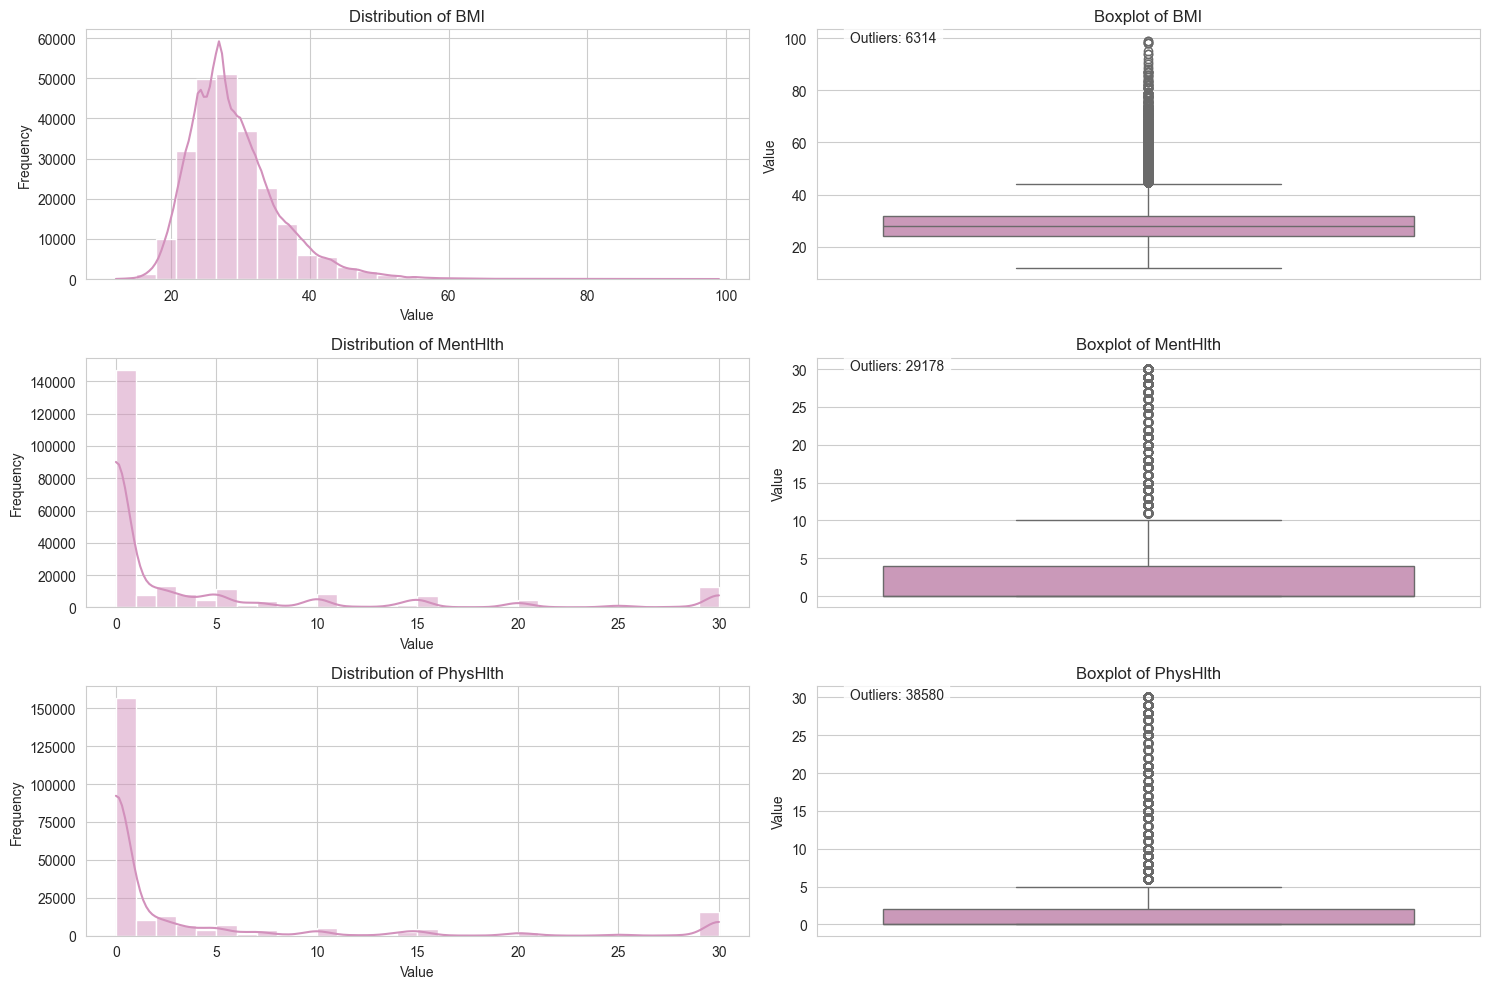

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of numerical columns
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth']

sns.set_style("whitegrid")
color = "#D291BC"

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(15, 10))

# Plot histograms and boxplots side by side
for i, col in enumerate(numerical_cols):
    # Histogram (Left column)
    sns.histplot(df[col], kde=True, color=color, ax=axes[i,0], bins=30)
    axes[i,0].set_title(f'Distribution of {col}')
    axes[i,0].set_xlabel('Value')
    axes[i,0].set_ylabel('Frequency')
    
    # Boxplot 
    sns.boxplot(y=df[col], color=color, ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot of {col}')
    axes[i,1].set_ylabel('Value')
    
    # Calculate and display outlier count for boxplot
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    axes[i,1].text(0.05, 0.95, f'Outliers: {len(outliers)}', 
                  transform=axes[i,1].transAxes,
                  bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

#### 1.4 Check Target Variables - Diabetes vs No Diabetes

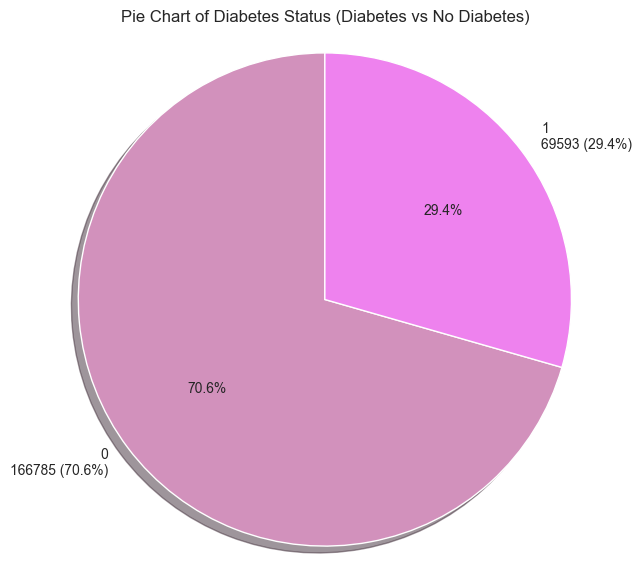

Diabetes_binary
0    166785
1     69593
Name: count, dtype: int64
Total: 236378 entries


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Diabetes_binary' is treated as integer
df['Diabetes_binary'] = df['Diabetes_binary'].astype(int)

# Get the counts for the 'Diabetes_binary' column
diabetes_counts = df['Diabetes_binary'].value_counts()

# Create labels with counts and percentages for the pie chart
labels = [f"{category}\n{count} ({count/sum(diabetes_counts)*100:.1f}%)" for category, count in diabetes_counts.items()]

# Create the pie chart
plt.figure(figsize=(7, 7))
plt.pie(diabetes_counts, labels=labels, autopct='%1.1f%%', 
        colors=["#D291BC", "#EE82EE"], startangle=90, shadow=True)
plt.title("Pie Chart of Diabetes Status (Diabetes vs No Diabetes)")
plt.axis('equal')
plt.show()

print(diabetes_counts)
print(f"Total: {diabetes_counts.sum()} entries")


#### 1.5 Correlation Heatmap (only numerical)

Correlation with target (Diabetes_binary):
Diabetes_binary         1.000000
DiffWalk                0.657843
HighBP                  0.462538
GenHlth                 0.392853
HighChol                0.379208
Age                     0.339170
PhysHlth                0.307926
HeartDiseaseorAttack    0.307896
BMI                     0.271830
Smoker                  0.238103
Stroke                  0.148615
CholCheck               0.091076
MentHlth                0.075408
AnyHealthcare           0.042872
Sex                     0.033482
NoDocCost               0.020988
HvyAlcoholConsump      -0.030408
Fruits                 -0.046657
Veggies                -0.059141
Education              -0.152566
PhysActivity           -0.213762
Income                 -0.222104
Name: Diabetes_binary, dtype: float64


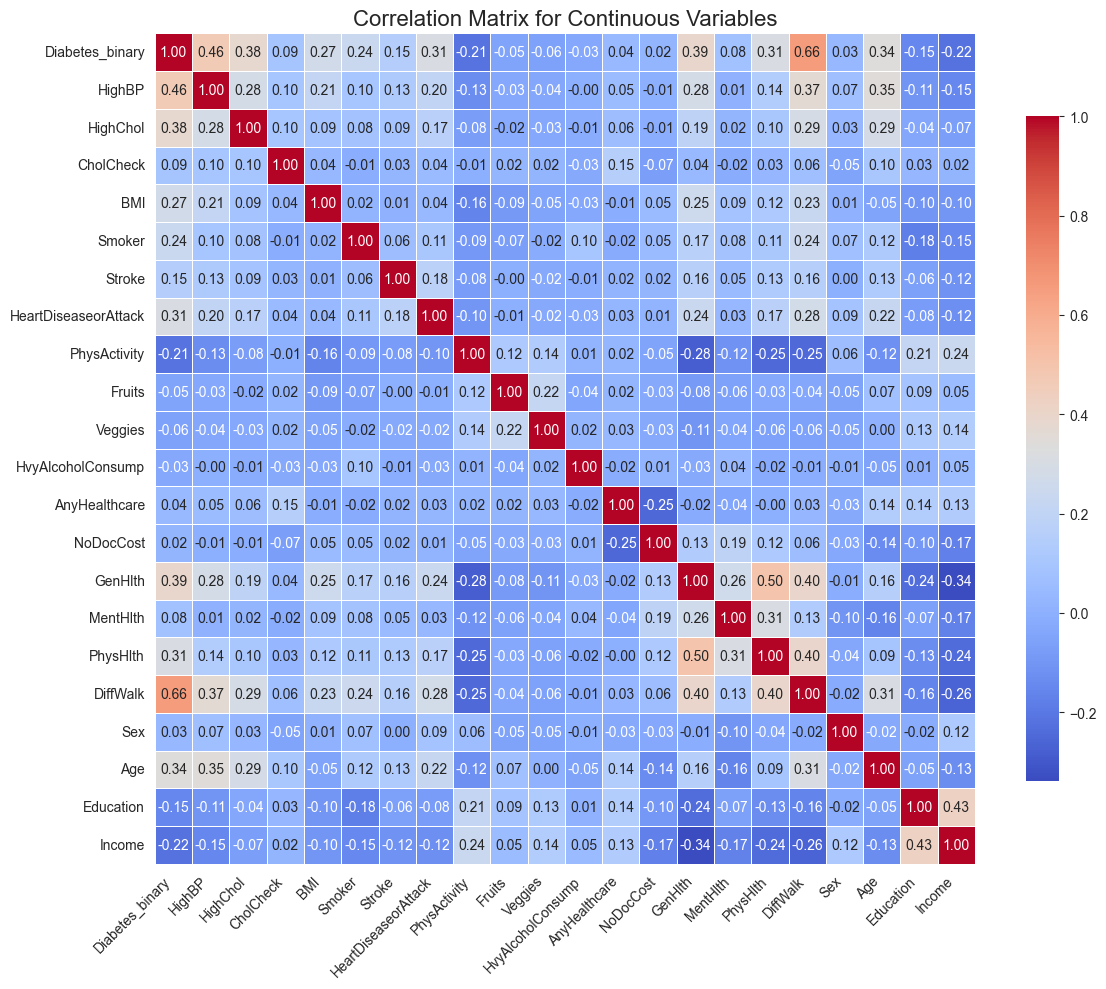


Chi-Square Test Results for Categorical Variables:


<Figure size 1200x800 with 0 Axes>

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

continuous_vars = df.select_dtypes(include=[np.number])
correlation_matrix = continuous_vars.corr()
target_correlation = correlation_matrix['Diabetes_binary'].sort_values(ascending=False)
print("Correlation with target (Diabetes_binary):")
print(target_correlation)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, 
            annot_kws={'size': 10}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix for Continuous Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

categorical_vars = df.select_dtypes(include=['object', 'bool']).columns
print("\nChi-Square Test Results for Categorical Variables:")

for var in categorical_vars:
    contingency_table = pd.crosstab(df[var], df['Diabetes_binary'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"\nChi-Square Test for {var} vs Diabetes_binary:")
    print(f"P-Value: {p_value}")
    if p_value < 0.05:
        print(f"Significant relationship between {var} and Diabetes_binary (p < 0.05).")
    else:
        print(f"No significant relationship between {var} and Diabetes_binary (p >= 0.05).")

plt.figure(figsize=(12, 8))
for idx, var in enumerate(categorical_vars):
    plt.subplot(2, 3, idx + 1)
    sns.countplot(data=df, x=var, hue='Diabetes_binary')
    plt.title(f'{var} vs Diabetes_binary')

plt.tight_layout()
plt.show()


### 2.0 Data Preprocessing 


#### 2.1 Missing Values

In [9]:
missing_values = df.isnull().sum() 
print(missing_values)

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocCost               0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


#### 2. Check Outliers

##### 2.1 Outliers for Categorical Variables - Education

In [10]:
# Check value counts and diabetes rates
print("Value counts:\n", df['Education'].value_counts().sort_index())
print("\nDiabetes rates:\n", df.groupby('Education')['Diabetes_binary'].mean())

Value counts:
 Education
1       147
2      2771
3      6940
4     52741
5     65377
6    108402
Name: count, dtype: int64

Diabetes rates:
 Education
1    0.448980
2    0.457957
3    0.450288
4    0.369428
5    0.332166
6    0.220780
Name: Diabetes_binary, dtype: float64


Original Value Counts:
 Education
1       147
2      2771
3      6940
4     52741
5     65377
6    108402
Name: count, dtype: int64


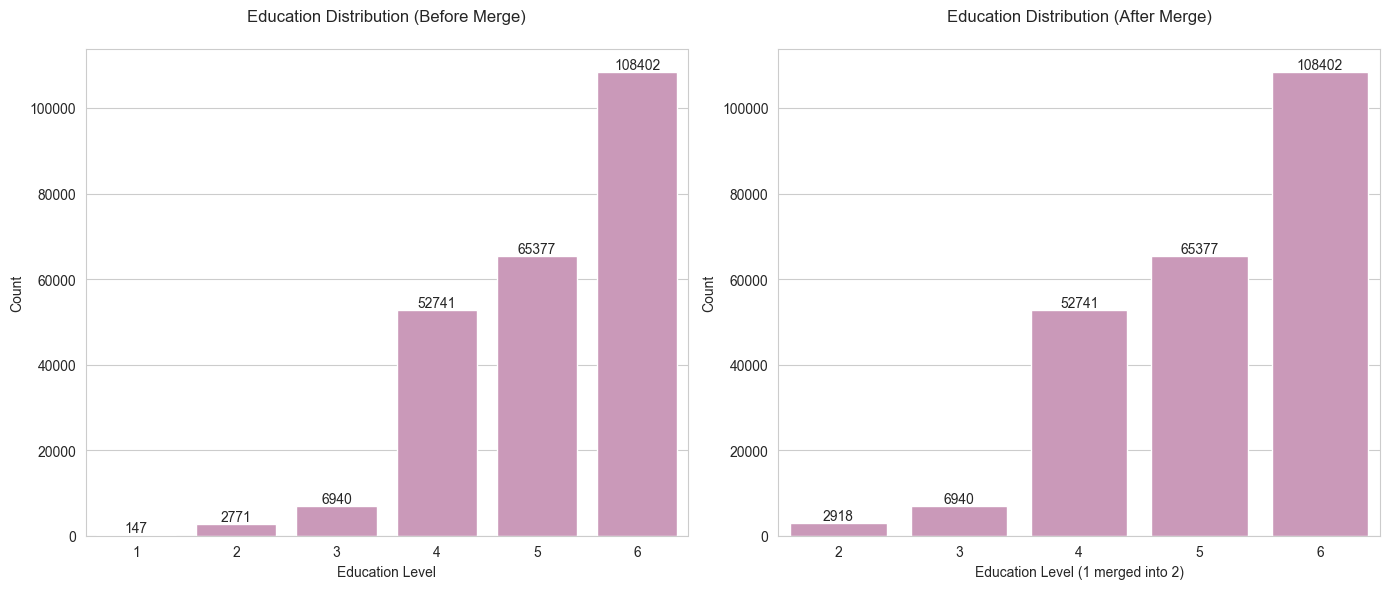


Final Education Level Counts:
 Education_Level
2      2918
3      6940
4     52741
5     65377
6    108402
Name: count, dtype: int64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Check original distribution
print("Original Value Counts:\n", df['Education'].value_counts().sort_index())

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='Education', data=df, 
                   order=sorted(df['Education'].unique()),
                   color="#D291BC")

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Education Distribution (Before Merge)', pad=20)
plt.xlabel('Education Level')
plt.ylabel('Count')

# Merge and rename in one step
df['Education_Level'] = df['Education'].replace(1, 2)  
df.drop('Education', axis=1, inplace=True) 

plt.subplot(1, 2, 2)
ax2 = sns.countplot(x='Education_Level', data=df,
                   order=sorted(df['Education_Level'].unique()),
                   color="#D291BC")

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Education Distribution (After Merge)', pad=20)
plt.xlabel('Education Level (1 merged into 2)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("\nFinal Education Level Counts:\n", df['Education_Level'].value_counts().sort_index())

df_clean = df.copy()

##### 2.2 Outliers for Numerical Variables

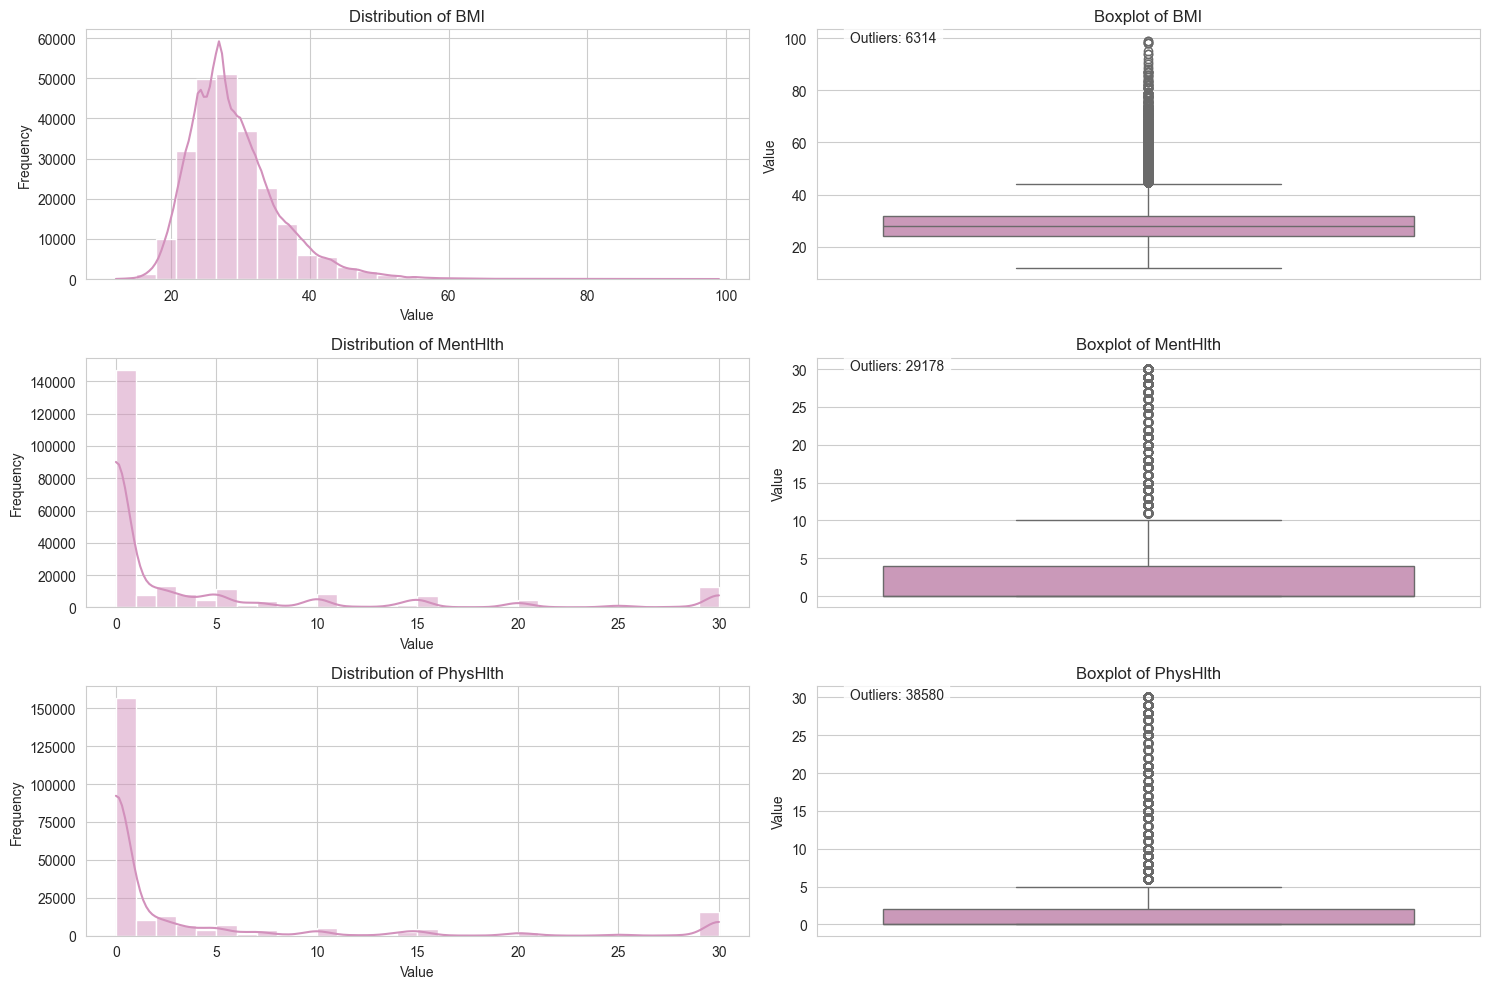

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numerical columns
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth']

sns.set_style("whitegrid")
color = "#D291BC"
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    # Histogram (Left column)
    sns.histplot(df[col], kde=True, color=color, ax=axes[i,0], bins=30)
    axes[i,0].set_title(f'Distribution of {col}')
    axes[i,0].set_xlabel('Value')
    axes[i,0].set_ylabel('Frequency')
    
    # Boxplot (Right column)
    sns.boxplot(y=df[col], color=color, ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot of {col}')
    axes[i,1].set_ylabel('Value')
    
    # Calculate and display outlier count for boxplot
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    axes[i,1].text(0.05, 0.95, f'Outliers: {len(outliers)}', 
                  transform=axes[i,1].transAxes,
                  bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Outliers for BMI (greater than 50):
               BMI
count  2102.000000
mean     56.831113
std       7.172753
min      51.000000
25%      52.000000
50%      55.000000
75%      59.000000
max      99.000000

Outliers for MentHlth (greater than 30):
       MentHlth
count       0.0
mean        NaN
std         NaN
min         NaN
25%         NaN
50%         NaN
75%         NaN
max         NaN

Outliers for PhysHlth (greater than 30):
       PhysHlth
count       0.0
mean        NaN
std         NaN
min         NaN
25%         NaN
50%         NaN
75%         NaN
max         NaN


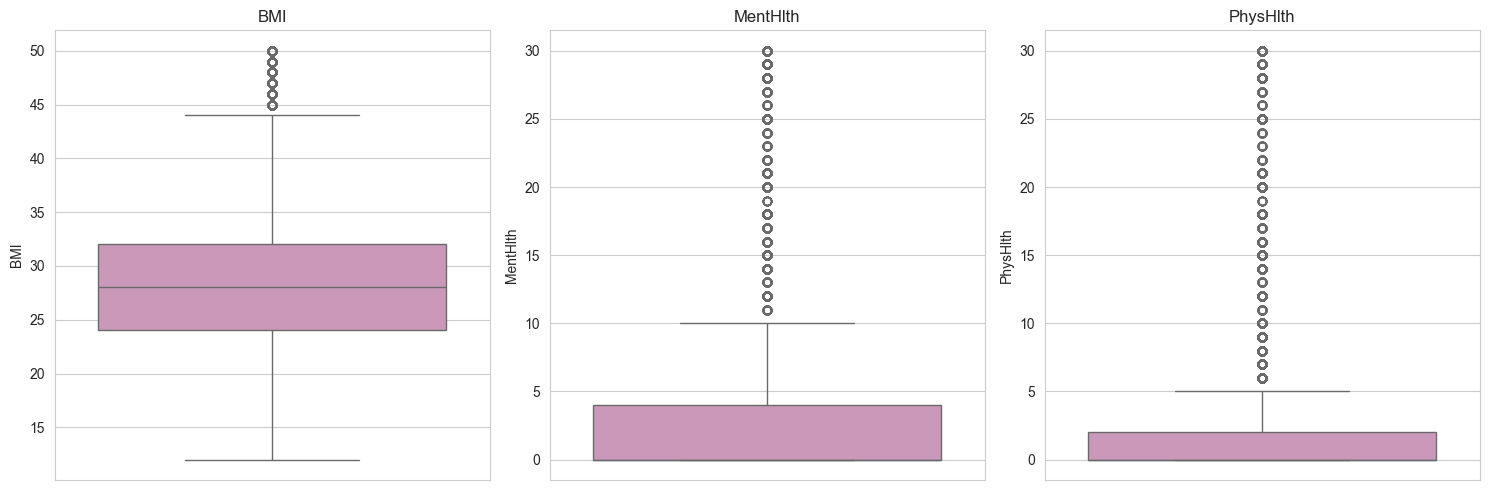

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  Validate outliers
print("Outliers for BMI (greater than 50):")
print(df[df['BMI'] > 50][['BMI']].describe())  

print("\nOutliers for MentHlth (greater than 30):")
print(df[df['MentHlth'] > 30][['MentHlth']].describe())  

print("\nOutliers for PhysHlth (greater than 30):")
print(df[df['PhysHlth'] > 30][['PhysHlth']].describe()) 

df_clean = df.copy()  

# Apply winsorization 
df_clean['BMI'] = df_clean['BMI'].clip(upper=50)
df_clean['MentHlth'] = df_clean['MentHlth'].clip(upper=30)
df_clean['PhysHlth'] = df_clean['PhysHlth'].clip(upper=30)

# Create visualizations 
plt.figure(figsize=(15, 5))

# Plot BMI boxplot
plt.subplot(1, 3, 1)
sns.boxplot(y=df_clean['BMI'], color="#D291BC")
plt.title('BMI')

# Plot MentHlth boxplot
plt.subplot(1, 3, 2)
sns.boxplot(y=df_clean['MentHlth'], color="#D291BC")
plt.title('MentHlth')

# Plot PhysHlth boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df_clean['PhysHlth'], color="#D291BC")
plt.title('PhysHlth')

plt.tight_layout()
plt.show()


### 3.0 Second part Data Preprocessing

#### 3.1 Feature Engineering

##### Standardization

In [14]:
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

# Numerical columns to standardize
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth']
scaler = StandardScaler()

# Apply standardization to the numerical columns
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])
scaled_data = df_clean[numerical_cols].head()
print(tabulate(scaled_data.round(2), headers='keys', tablefmt='pretty'))


+---+-------+----------+----------+
|   |  BMI  | MentHlth | PhysHlth |
+---+-------+----------+----------+
| 0 | -2.21 |   0.77   |   1.97   |
| 1 | -0.14 |   -0.5   |  -0.45   |
| 2 | 0.65  |   0.77   |  -0.45   |
| 3 | 0.02  |   -0.5   |   3.18   |
| 4 | -0.78 |   -0.5   |  -0.45   |
+---+-------+----------+----------+


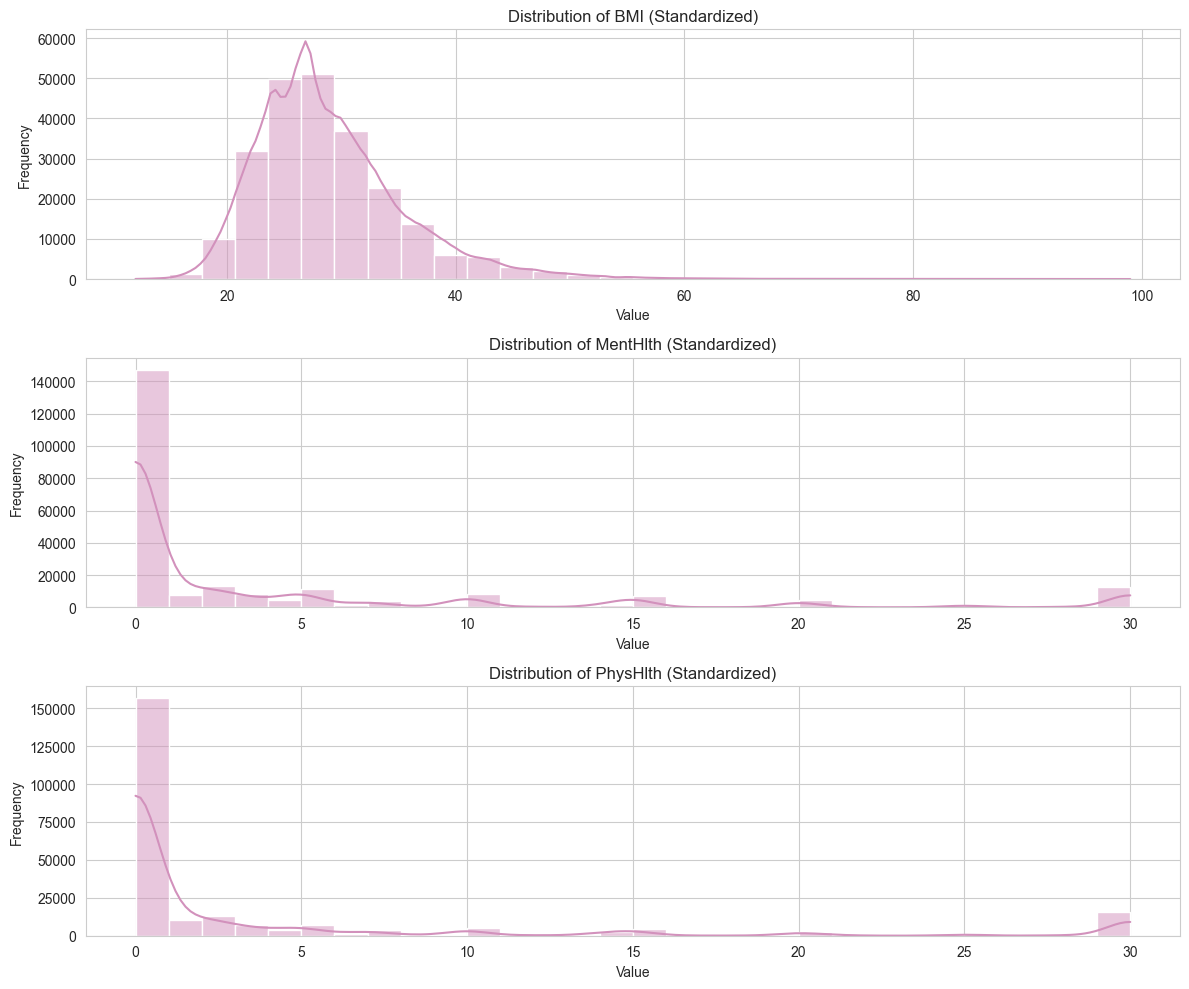

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Numerical columns
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth']
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(12, 10))

if len(numerical_cols) == 1:
    axes = [axes]

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, color='#D291BC', ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col} (Standardized)')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


#### Minimize Age from 13 groups to 4 groups


Age Group Distribution:
Age_Group
1    61092
2    63002
3    80343
4    31941
Name: count, dtype: int64


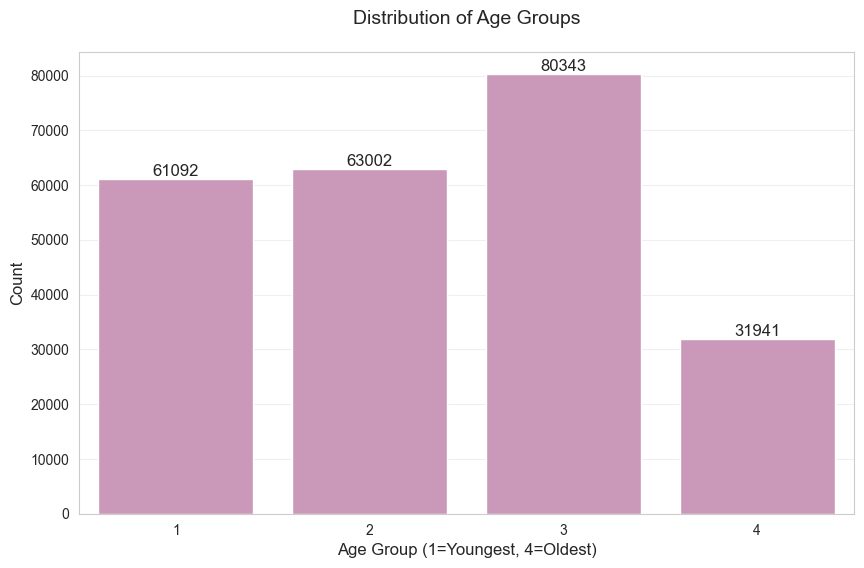

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Bin the Age column
bins = [0, 5, 8, 11, 13]  
labels = [1, 2, 3, 4]     
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, include_lowest=True).astype(int)

# Drop the original Age column
df_clean.drop('Age', axis=1, inplace=True)

# Verification
print("\nAge Group Distribution:")
print(df_clean['Age_Group'].value_counts().sort_index())

# Create Age Group bar chart
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Age_Group', data=df_clean, color='#D291BC')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title('Distribution of Age Groups', fontsize=14, pad=20)
plt.xlabel('Age Group (1=Youngest, 4=Oldest)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Check data types after conversion

In [17]:
# Print data types after scaling
print(df_clean.dtypes)

Diabetes_binary           int32
HighBP                    int64
HighChol                  int64
CholCheck                 int64
BMI                     float64
Smoker                    int64
Stroke                    int64
HeartDiseaseorAttack      int64
PhysActivity              int64
Fruits                    int64
Veggies                   int64
HvyAlcoholConsump         int64
AnyHealthcare             int64
NoDocCost                 int64
GenHlth                   int64
MentHlth                float64
PhysHlth                float64
DiffWalk                  int64
Sex                       int64
Income                    int64
Education_Level           int64
Age_Group                 int32
dtype: object


### 4.0 Preparation before building model - Train and Test , SMOTE

#### Check Target Variable Count

In [18]:
# Check Target Variable
print(df_clean['Diabetes_binary'].value_counts())

Diabetes_binary
0    166785
1     69593
Name: count, dtype: int64


#### Split TRAIN and TEST

In [19]:
from sklearn.model_selection import train_test_split

# Include ALL features (mixed types)
X = df_clean.drop('Diabetes_binary', axis=1)  # Features
y = df_clean['Diabetes_binary']  # Target

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the size of the splits
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 189102
Test set size: 47276


#### SMOTE Techniques for class imbalance

In [20]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training set to balance the classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the class distribution after SMOTE
print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

Class distribution after SMOTE:
Diabetes_binary
1    133406
0    133406
Name: count, dtype: int64


#### Visualition after doing class imbalance

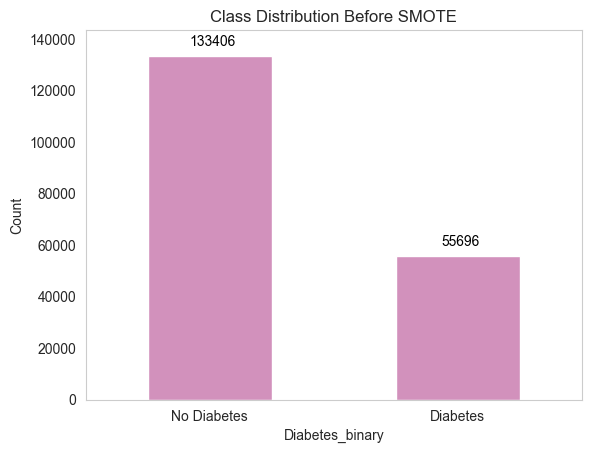

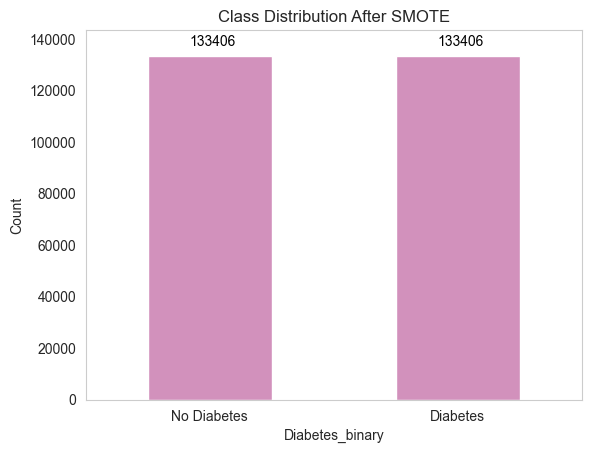

In [21]:
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Include ALL features (mixed types)
X = df_clean.drop('Diabetes_binary', axis=1)  # Features
y = df_clean['Diabetes_binary']  # Target

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize the class distribution before SMOTE
ax = y_train.value_counts().plot(kind='bar', title='Class Distribution Before SMOTE', color="#D291BC")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'], rotation=0)  
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(2, 10), textcoords='offset points')
plt.ylim(0, max(y_train.value_counts()) + 10000)
plt.grid(False)
plt.tick_params(axis="x", bottom=False)
plt.show()

# Apply SMOTE to the training set to balance the classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Visualize the class distribution after SMOTE
ax = y_train_smote.value_counts().plot(kind='bar', title='Class Distribution After SMOTE', color="#D291BC")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'], rotation=0)  
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(2, 10), textcoords='offset points')
plt.ylim(0, max(y_train_smote.value_counts()) + 10000)
plt.grid(False)
plt.tick_params(axis="x", bottom=False)
plt.show()


In [22]:
print("[Test] class distribution:")
test_counts = y_test.value_counts()
print(test_counts)
print("Total:", test_counts.sum())

[Test] class distribution:
Diabetes_binary
0    33379
1    13897
Name: count, dtype: int64
Total: 47276


### 5.0 Model Building

## Deep Neural Networks Base Model (DNNs)

### DNN (Base)


BUILDING BASE DNN MODEL ARCHITECTURE

Input shape: 21 features
Added Dense layer with 64 units and ReLU activation
Added Dense layer with 32 units and ReLU activation
Added Output layer with 1 unit and sigmoid activation

Model Architecture Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING THE BASE DNN MODEL

Starting model training...
Epoch 1/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.8564 - f1_metric: 0.8493 - loss: 0.3424 - precision_metric: 0.8710 - recall_metric: 0.8384 - val_accuracy: 0.8874 - val_f1_metric: 0.8047 - val_loss: 0.3056 - val_precision_metric: 0.7947 - val_recall_metric: 0.8338
Epoch 2/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8637 - f1_metric: 0.8554 - loss: 0.3270 - precision_metric: 0.8855 - recall_metric: 0.8356 - val_accuracy: 0.8819 - val_f1_metric: 0.7998 - val_loss: 0.3097 - val_precision_metric: 0.7731 - val_recall_metric: 0.8486
Epoch 3/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.8653 - f1_metric: 0.8566 - loss: 0.3235 - precision_metric: 0.8900 - recall_metric: 0.8338 - val_accuracy: 0.8906 - val_f1_metric: 0.8076 - val_loss: 0.3087 - val_precision_metric: 0.8075 - val_recall_metric: 0.8266
Epoch 4/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.8658 - f1_metric: 0

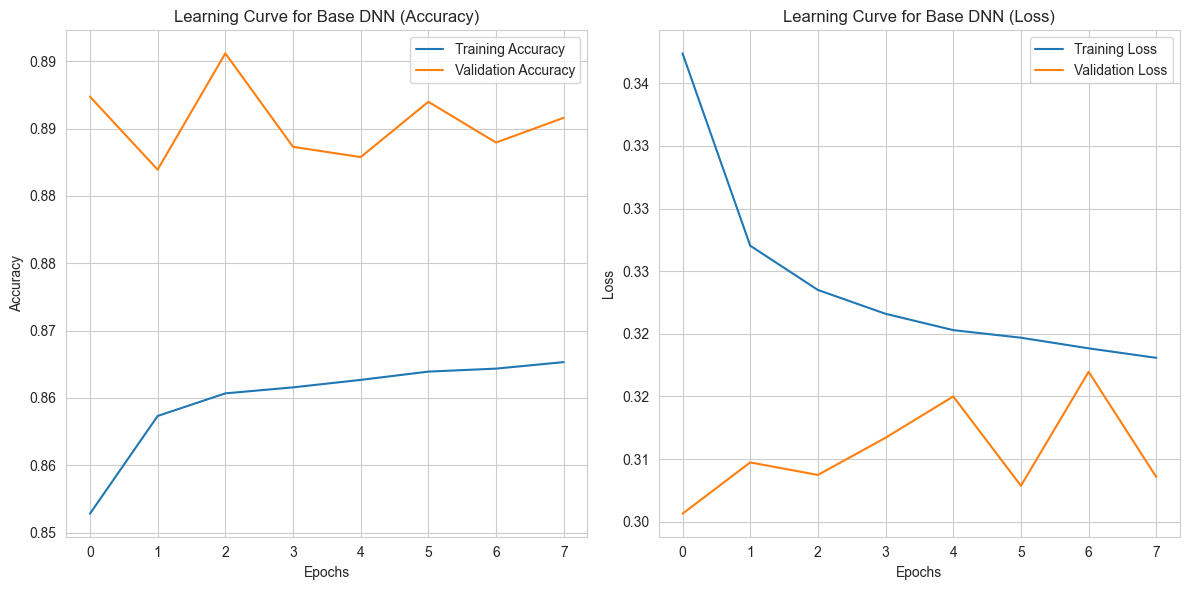

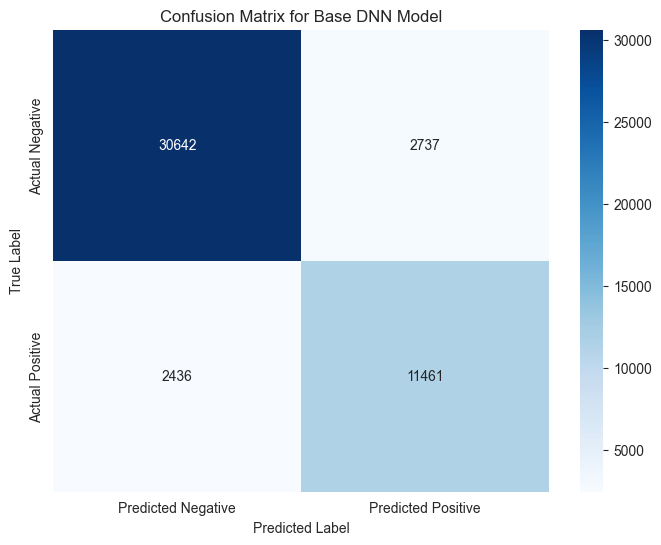

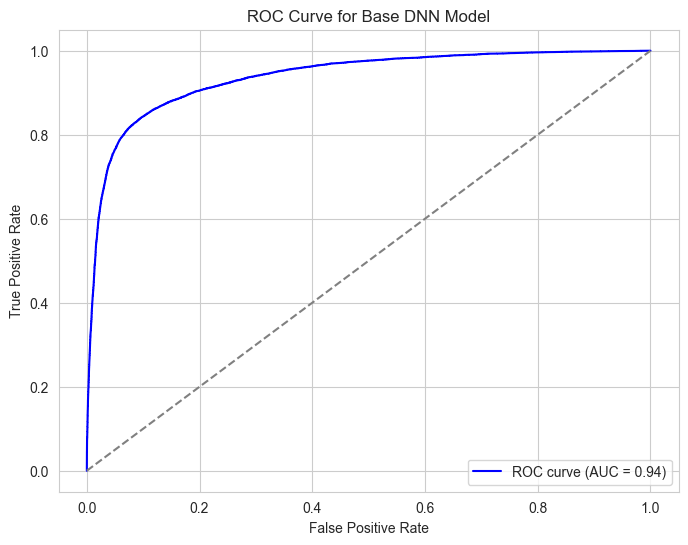

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import backend as K
from matplotlib.ticker import FuncFormatter

# Custom F1-Score Metric
def precision_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    return tp / (tp + fp + K.epsilon())

def recall_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    return tp / (tp + fn + K.epsilon())

def f1_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    
    # Avoid division by zero
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    
    return 2 * (precision * recall) / (precision + recall + K.epsilon())

# ==============================================
# DNN BASE MODEL ARCHITECTURE
# ==============================================
print("\n" + "="*50)
print("BUILDING BASE DNN MODEL ARCHITECTURE")
print("="*50)

# Deep Neural Network (DNN) 
model = Sequential()

# Input layer 
input_shape = X_train_smote.shape[1]
print(f"\nInput shape: {input_shape} features")

# Use Input layer to define the input shape
model.add(Input(shape=(input_shape,)))  

# First hidden layer
model.add(Dense(64, activation='relu'))
print("Added Dense layer with 64 units and ReLU activation")

# Second hidden layer
model.add(Dense(32, activation='relu'))
print("Added Dense layer with 32 units and ReLU activation")

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))
print("Added Output layer with 1 unit and sigmoid activation")

# Compile the model
model.compile(loss='binary_crossentropy', 
              optimizer=Adam(learning_rate=0.001), 
              metrics=['accuracy', precision_metric, recall_metric , f1_metric])  

# Model architecture
print("\nModel Architecture Summary:")
model.summary()

# ==============================================
# BASE MODEL TRAINING
# ==============================================
print("\n" + "="*50)
print("TRAINING THE BASE DNN MODEL")
print("="*50)

# Add EarlyStopping to avoid overfitting
early_stopping = EarlyStopping(
    monitor='val_f1_metric',
    mode='max',  
    patience=5,
    restore_best_weights=True
)

# Train the model
print("\nStarting model training...")
history = model.fit(X_train_smote, y_train_smote, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping],
                    verbose=1)

# ==============================================
# MODEL EVALUATION
# ==============================================
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Evaluate the model on the test data
y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int) 

# Calculate accuracy and print metrics
accuracy = accuracy_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)  
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# ==============================================
# VISUALIZATIONS
# ==============================================
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Curve for Base DNN (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve for Base DNN (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.show()

# 2. Confusion Matrix 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Base DNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Calculate ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Base DNN Model')
plt.legend(loc='lower right')
plt.show()

### DNN (Tuned)

Trial 15 Complete [00h 19m 33s]
val_f1_score: 0.818837266556466

Best val_f1_score So Far: 0.8197804540125759
Total elapsed time: 02h 19m 31s

BUILDING DNN MODEL WITH BEST PARAMETERS

Model Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 96)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,385 (32.75 KB)

 Trainable params: 8,385 (32.75 KB)

 Non-trainable params: 0 (0.00 B)


=== DNN BEST HYPERPARAMETERS ===
First layer units: 96
Second layer units: 64
Dropout rate: 0.50
Learning rate: 0.000140
Batch size: 48
L2 regularization: 0.000250

TRAINING FINAL DNN MODEL
Epoch 1/50
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8425 - f1_metric: 0.8381 - loss: 0.3945 - val_accuracy: 0.8806 - val_f1_metric: 0.7982 - val_loss: 0.3327
Epoch 2/50
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8594 - f1_metric: 0.8533 - loss: 0.3600 - val_accuracy: 0.8747 - val_f1_metric: 0.7939 - val_loss: 0.3379
Epoch 3/50
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8604 - f1_metric: 0.8541 - loss: 0.3545 - val_accuracy: 0.8778 - val_f1_metric: 0.7975 - val_loss: 0.3283
Epoch 4/50
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8616 - f1_metric: 0.8551 - loss: 0.3512 - val_accuracy: 0.8810 - val_f1_metric: 0.8005 - val_loss: 0.3265
Epoch 5/50
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8627 - f1_metric: 0.8560 - loss: 0.3482 - v

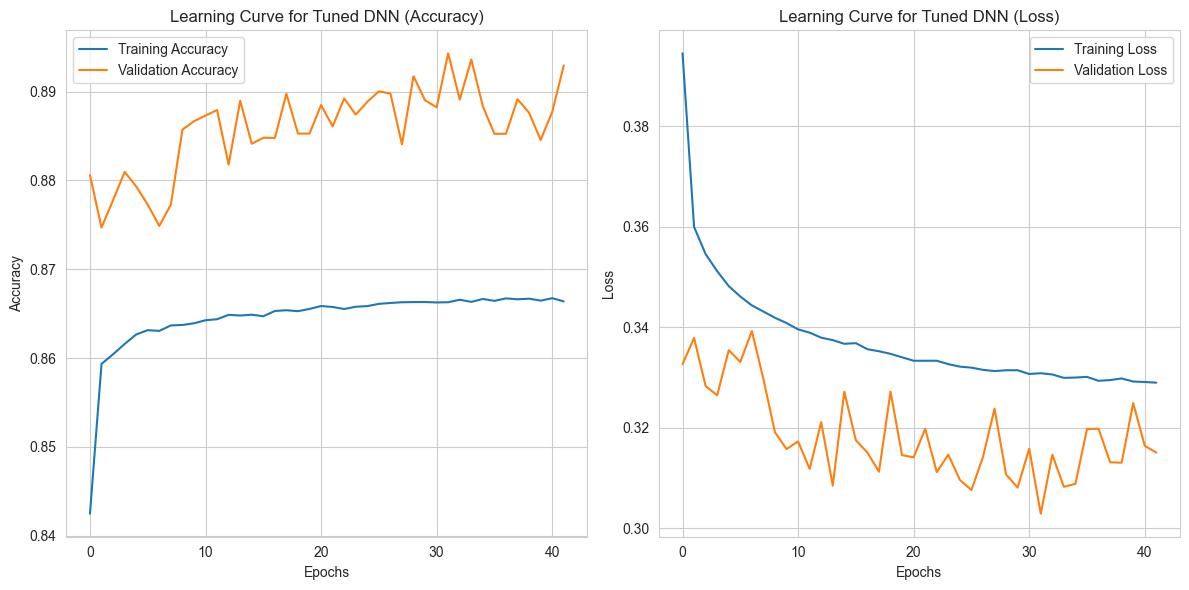

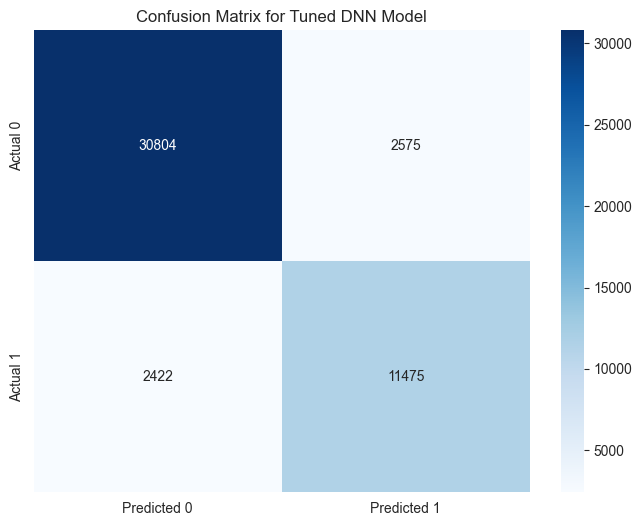

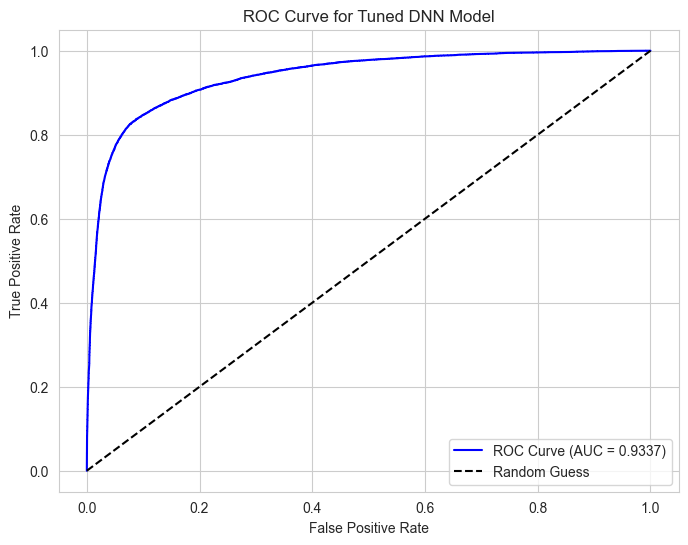

In [ ]:
import numpy as np
import pandas as pd
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras import regularizers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import backend as K
import tensorflow as tf
from matplotlib.ticker import FuncFormatter

def precision_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    return tp / (tp + fp + K.epsilon())

def recall_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    return tp / (tp + fn + K.epsilon())

def f1_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    
    # Avoid division by zero
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    
    return 2 * (precision * recall) / (precision + recall + K.epsilon())

# Callback for F1-Score
class F1ScoreCallback(Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.X_val = validation_data[0]
        self.y_val = validation_data[1]
    
    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val, verbose=0)
        y_pred_class = (y_pred > 0.5).astype(int)
        f1 = f1_score(self.y_val, y_pred_class)
        logs['val_f1_score'] = f1  

# Hypermodel for Keras Tuner
class MyHyperModel(kt.HyperModel):
    def build(self, hp):
        model = Sequential()
        input_shape = X_train_smote.shape[1]
        
        # Input layer
        model.add(Input(shape=(input_shape,)))
        
        # First hidden layer 
        model.add(Dense(
            units=hp.Int('units_1', min_value=32, max_value=128, step=32),
            activation='relu',
            kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 1e-4, 1e-2, sampling='log'))
        ))
        
        # Second hidden layer 
        model.add(Dense(
            units=hp.Int('units_2', min_value=32, max_value=128, step=32),
            activation='relu',
            kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 1e-4, 1e-2, sampling='log'))
        ))
        
        # Dropout layer 
        model.add(Dropout(
            hp.Float('dropout', min_value=0.3, max_value=0.6, step=0.1)
        ))
        
        # Output layer
        model.add(Dense(1, activation='sigmoid'))
        
        # Compile with tuneable learning rate
        model.compile(
            optimizer=Adam(
                hp.Float('lr', min_value=1e-5, max_value=1e-2, sampling='log')
            ),
            loss='binary_crossentropy',
            metrics=['accuracy', precision_metric, recall_metric, f1_metric] 
        )
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        # Add F1 callback if validation data exists
        if 'validation_data' in kwargs:
            callbacks = kwargs.pop('callbacks', [])
            callbacks.append(F1ScoreCallback(kwargs['validation_data']))
            kwargs['callbacks'] = callbacks
        
        return model.fit(
            *args,
            batch_size=hp.Int('batch_size', min_value=16, max_value=64, step=16),
            **kwargs
        )

# Initialize RandomSearch tuner with F1 objective
tuner = kt.RandomSearch(
    MyHyperModel(),
    objective=kt.Objective('val_f1_score', direction='max'), 
    max_trials=15,
    executions_per_trial=1,
    directory='dnn_tuning_results',
    project_name='dnn_tuning',
    overwrite=True,
    max_consecutive_failed_trials=5
)

early_stopping = EarlyStopping(
    monitor='val_f1_metric',
    patience=10,
    mode='max',
    restore_best_weights=True
)

# ==============================================
# RUN HYPERPARAMETER TUNING
# ==============================================
print("\n" + "="*50)
print("STARTING DNN HYPERPARAMETER TUNING")
print("="*50)

tuner.search(
    X_train_smote, 
    y_train_smote,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# ==============================================
# BUILD FINAL MODEL WITH BEST HYPERPARAMETERS
# ==============================================
print("\n" + "="*50)
print("BUILDING DNN MODEL WITH BEST PARAMETERS")
print("="*50)

# Best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model
model = Sequential()
model.add(Input(shape=(X_train_smote.shape[1],)))

# Add layers with tuned parameters
model.add(Dense(
    best_hps.get('units_1'), 
    activation='relu',
    kernel_regularizer=regularizers.l2(best_hps.get('l2_reg'))
))
model.add(Dense(
    best_hps.get('units_2'), 
    activation='relu',
    kernel_regularizer=regularizers.l2(best_hps.get('l2_reg'))
))
model.add(Dropout(best_hps.get('dropout')))
model.add(Dense(1, activation='sigmoid'))

# Compile with tuned learning rate
model.compile(
    optimizer=Adam(learning_rate=best_hps.get('lr')),
    loss='binary_crossentropy',
    metrics=['accuracy', f1_metric]
)

print("\nModel Architecture Summary:")
model.summary()

# Best hyperparameters
print("\n=== DNN BEST HYPERPARAMETERS ===")
print(f"First layer units: {best_hps.get('units_1')}")
print(f"Second layer units: {best_hps.get('units_2')}")
print(f"Dropout rate: {best_hps.get('dropout'):.2f}")
print(f"Learning rate: {best_hps.get('lr'):.6f}")
print(f"Batch size: {best_hps.get('batch_size')}")
print(f"L2 regularization: {best_hps.get('l2_reg'):.6f}")

# ==============================================
# TRAIN FINAL MODEL
# ==============================================
print("\n" + "="*50)
print("TRAINING FINAL DNN MODEL")
print("="*50)

history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=best_hps.get('batch_size'),
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# ==============================================
# MODEL EVALUATION
# ==============================================
print("\n" + "="*50)
print("DNN MODEL EVALUATION")
print("="*50)

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, digits=2))

# ==============================================
# VISUALIZATIONS
# ==============================================
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Curve for Tuned DNN (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve for Tuned DNN (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_class), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Tuned DNN Model')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='b')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  

# Labeling the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned DNN Model')
plt.legend(loc='lower right') 
plt.show()


## Convolutional Neural Network (CNN)

#### CNN (Base)


BUILDING BASE CNN MODEL ARCHITECTURE

Input shape: (21,) features
Added Input layer with shape (21,)
Added Reshape layer to convert 21 features to (features, 1) for Conv1D
Added Conv1D layer with 64 filters, kernel_size=3, and ReLU activation
Added MaxPooling1D layer with pool_size=2
Added Conv1D layer with 32 filters, kernel_size=2, and ReLU activation
Added Flatten layer
Added Dense layer with 32 units and ReLU activation
Added Dropout layer with rate=0.5
Added Output layer with 1 unit and sigmoid activation

Model Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 21, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 19, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,641 (49.38 KB)

 Trainable params: 12,641 (49.38 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING THE CNN MODEL

Starting model training...
Epoch 1/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8514 - f1_metric: 0.8422 - loss: 0.3660 - precision_metric: 0.8743 - recall_metric: 0.8218 - val_accuracy: 0.8670 - val_f1_metric: 0.7823 - val_loss: 0.3595 - val_precision_metric: 0.7360 - val_recall_metric: 0.8564
Epoch 2/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.8572 - f1_metric: 0.8479 - loss: 0.3542 - precision_metric: 0.8836 - recall_metric: 0.8236 - val_accuracy: 0.8705 - val_f1_metric: 0.7861 - val_loss: 0.3327 - val_precision_metric: 0.7445 - val_recall_metric: 0.8539
Epoch 3/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.8584 - f1_metric: 0.8489 - loss: 0.3517 - precision_metric: 0.8864 - recall_metric: 0.8227 - val_accuracy: 0.8755 - val_f1_metric: 0.7917 - val_loss: 0.3276 - val_precision_metric: 0.7575 - val_recall_metric: 0.8499
Epoch 4/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.8591 - f1_metric: 0.8492

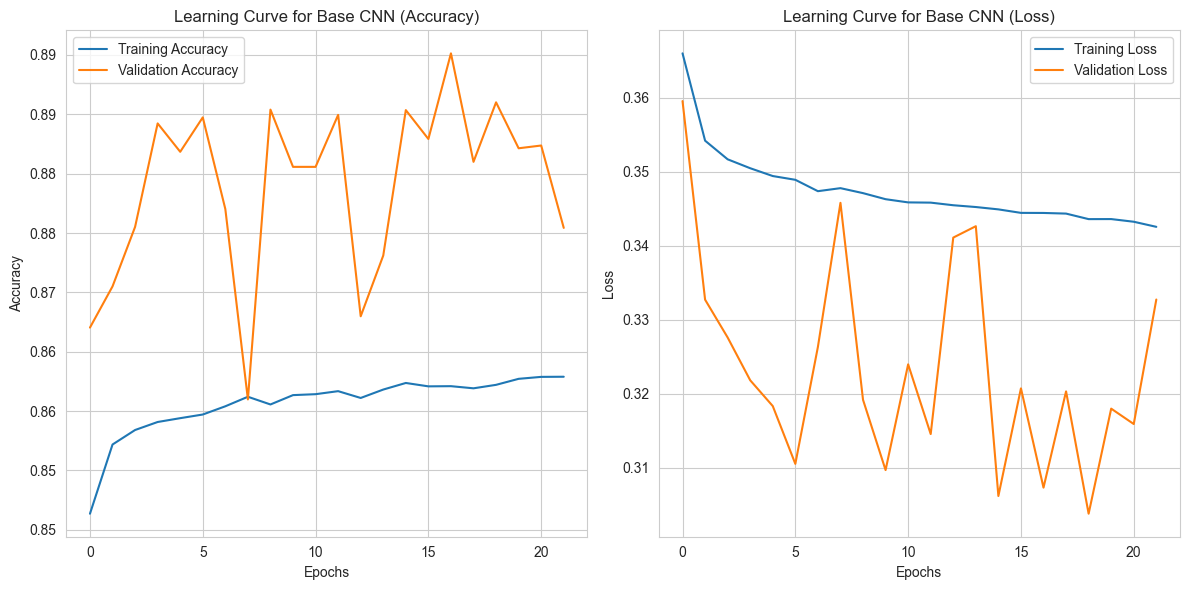

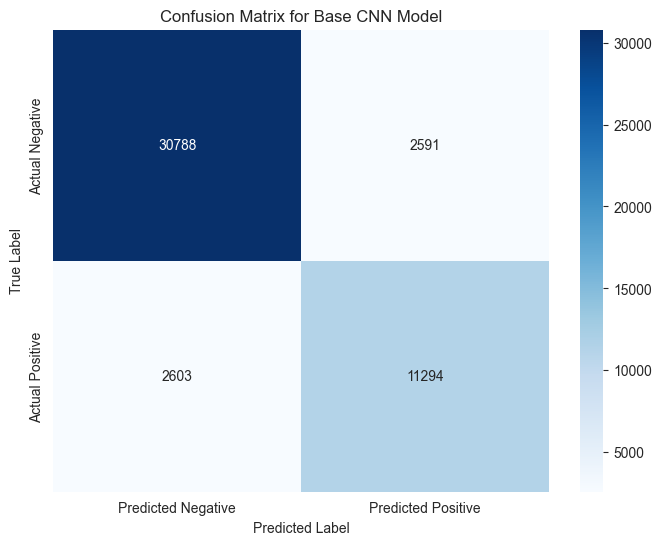

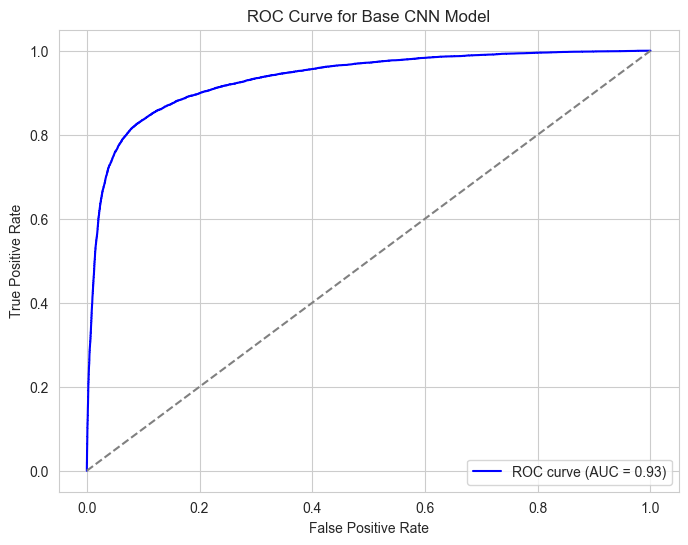

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from matplotlib.ticker import FuncFormatter

def precision_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    return tp / (tp + fp + K.epsilon())

def recall_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    return tp / (tp + fn + K.epsilon())

def f1_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())

    return 2 * (precision * recall) / (precision + recall + K.epsilon())

# ==============================================
# CNN MODEL ARCHITECTURE 
# ==============================================
print("\n" + "="*50)
print("BUILDING BASE CNN MODEL ARCHITECTURE")
print("="*50)

# Build the CNN model
model = Sequential()

# Input shape for 1D convolution
input_shape = X_train_smote.shape[1:]
print(f"\nInput shape: {input_shape} features")

model.add(Input(shape=input_shape))  
model.add(Reshape((input_shape[0], 1))) 
print(f"Added Input layer with shape {input_shape}")
print(f"Added Reshape layer to convert {input_shape[0]} features to (features, 1) for Conv1D")

# First Conv1D layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
print("Added Conv1D layer with 64 filters, kernel_size=3, and ReLU activation")

# Pooling layer
model.add(MaxPooling1D(pool_size=2))
print("Added MaxPooling1D layer with pool_size=2")

# Second Conv1D layer
model.add(Conv1D(filters=32, kernel_size=2, activation='relu'))
print("Added Conv1D layer with 32 filters, kernel_size=2, and ReLU activation")

# Flatten layer to transition to dense layers
model.add(Flatten())
print("Added Flatten layer")

# Dense layer
model.add(Dense(32, activation='relu'))
print("Added Dense layer with 32 units and ReLU activation")

# Dropout for regularization
model.add(Dropout(0.5))
print("Added Dropout layer with rate=0.5")

# Output layer 
model.add(Dense(1, activation='sigmoid'))
print("Added Output layer with 1 unit and sigmoid activation")

# Compile the model
model.compile(loss='binary_crossentropy', 
              optimizer=Adam(learning_rate=0.001), 
              metrics=['accuracy', precision_metric, recall_metric, f1_metric])  

# Model architecture
print("\nModel Architecture Summary:")
model.summary()

# ==============================================
# MODEL TRAINING
# ==============================================
print("\n" + "="*50)
print("TRAINING THE CNN MODEL")
print("="*50)

# Add EarlyStopping to avoid overfitting
early_stopping = EarlyStopping(
    monitor='val_f1_metric',
    mode='max',
    patience=5,
    restore_best_weights=True
)

# Train the model
print("\nStarting model training...")
history = model.fit(X_train_smote, y_train_smote, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping],
                    verbose=1)

# ==============================================
# MODEL EVALUATION
# ==============================================
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Evaluate the model on the test data
y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int)

# Calculate accuracy and print metrics
accuracy = accuracy_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class) 
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# ==============================================
# VISUALIZATIONS
# ==============================================
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Curve for Base CNN (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve for Base CNN (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.show()

# Confusion Matrix 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Base CNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Calculate ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Base CNN Model')
plt.legend(loc='lower right')
plt.show()


### CNN (Tuned)

Trial 15 Complete [00h 33m 05s]
val_f1_metric: 0.8124811053276062

Best val_f1_metric So Far: 0.8149641156196594
Total elapsed time: 03h 49m 00s

=== CNN BEST HYPERPARAMETERS ===
Number of Conv Blocks: 3
Conv Layer 1 filters: 64
Conv Layer 1 kernel size: 5
Conv Layer 2 filters: 128
Conv Layer 2 kernel size: 5
Conv Layer 3 filters: 96
Conv Layer 3 kernel size: 4
Number of Dense Layers: 2
Dense Layer 1 units: 96
Dense Layer 1 dropout: 0.4
Dense Layer 2 units: 64
Dense Layer 2 dropout: 0.3
Learning rate: 0.0012

BUILDING CNN MODEL WITH BEST PARAMETERS



Model Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 21, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 5, 96)          │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 2, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,521 (451.25 KB)

 Trainable params: 115,521 (451.25 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING FINAL CNN MODEL
Epoch 1/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 104s 12ms/step - accuracy: 0.8587 - f1_metric: 0.8498 - loss: 0.3451 - precision_metric: 0.8842 - recall_metric: 0.8272 - val_accuracy: 0.8789 - val_f1_metric: 0.7972 - val_loss: 0.3121 - val_precision_metric: 0.7643 - val_recall_metric: 0.8534
Epoch 2/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - accuracy: 0.8643 - f1_metric: 0.8550 - loss: 0.3318 - precision_metric: 0.8928 - recall_metric: 0.8284 - val_accuracy: 0.8858 - val_f1_metric: 0.8050 - val_loss: 0.3029 - val_precision_metric: 0.7838 - val_recall_metric: 0.8467
Epoch 3/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - accuracy: 0.8655 - f1_metric: 0.8561 - loss: 0.3285 - precision_metric: 0.8951 - recall_metric: 0.8280 - val_accuracy: 0.8858 - val_f1_metric: 0.8049 - val_loss: 0.3144 - val_precision_metric: 0.7825 - val_recall_metric: 0.8479
Epoch 4/50
8338/8338 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - accuracy: 0.8667 - f1_metric: 0.8575 - loss: 0.3270 - precis

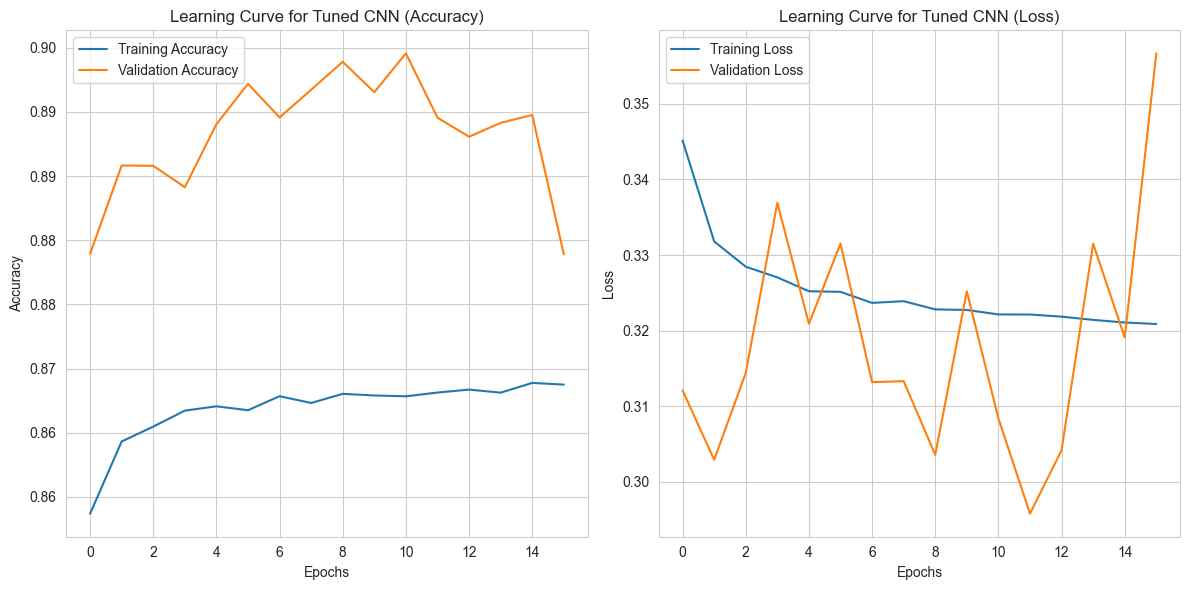

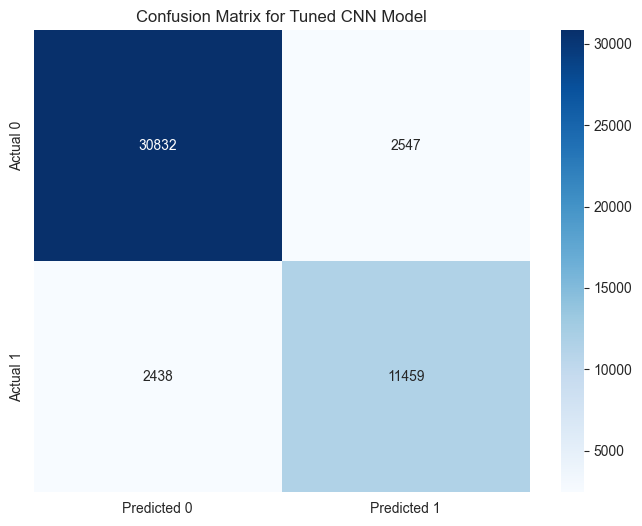

<Figure size 800x600 with 0 Axes>

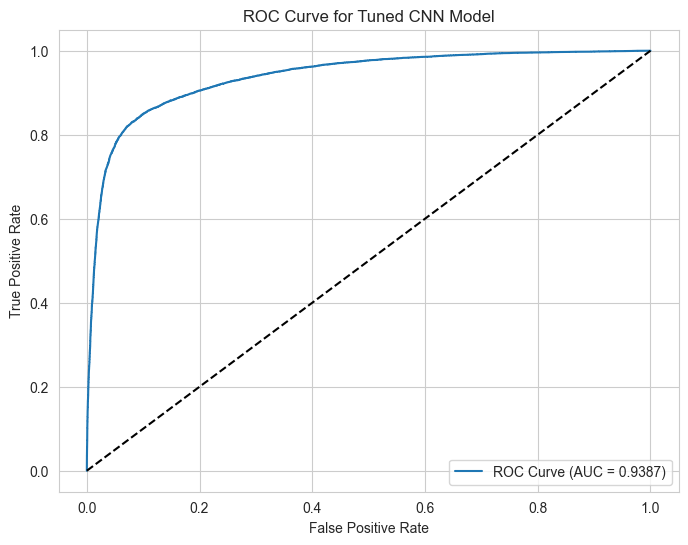

In [23]:
import numpy as np
import pandas as pd
import keras_tuner as kt
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Reshape, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, Callback
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import backend as K
from matplotlib.ticker import FuncFormatter
from tensorflow.keras.layers import Input

# ==============================================
#  METRIC FUNCTION
# ==============================================
def precision_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    return tp / (tp + fp + K.epsilon())

def recall_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    tp = K.sum(y_true * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    return tp / (tp + fn + K.epsilon())

def f1_metric(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, 'float32'))
    y_pred = K.flatten(K.round(y_pred))
    
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())

    return 2 * (precision * recall) / (precision + recall + K.epsilon())

# ==============================================
# HYPERPARAMETER TUNING MODEL
# ==============================================
def build_tunable_cnn(hp):
    model = Sequential()
    model.add(Input(shape=(X_train_smote.shape[1], 1)))
    
    # Conv Blocks
    for i in range(hp.Int('conv_blocks', 2, 4)):
        model.add(Conv1D(
            filters=hp.Int(f'filters_{i}', 64, 128, step=32),
            kernel_size=hp.Int(f'kernel_{i}', 3, 5),
            activation='relu',
            padding='same'
        ))
        model.add(MaxPooling1D(2))
    
    model.add(Flatten())
    
    # Dense Layers
    for i in range(hp.Int('dense_layers', 1, 2)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', 64, 128, step=32),
            activation='relu'
        ))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.3, 0.5, step=0.1)))
    
    model.add(Dense(1, activation='sigmoid'))
    
    # Learning rate
    optimizer = Adam(hp.Float('lr', 1e-5, 1e-2, sampling='log'))
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', precision_metric, recall_metric, f1_metric]
    )
    return model

# ==============================================
# TUNER SETUP 
# ==============================================
tuner = kt.RandomSearch(
    build_tunable_cnn,
    objective=kt.Objective('val_f1_metric', direction='max'),
    max_trials=15,
    directory='cnn_tuning_results',
    project_name='cnn_tuning',
    overwrite=True
)

early_stop = EarlyStopping(
    monitor='val_f1_metric',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# ==============================================
# BEST HYPERPARAMTERS
# ==============================================
print("\n=== STARTING CNN HYPERPARAMETER TUNING ===")
tuner.search(
    X_train_smote, y_train_smote,
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[early_stop],
    verbose=1,
    batch_size=32  
)

# Get the best hyperparameters from the tuning process
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Best Hyperparamters
print("\n=== CNN BEST HYPERPARAMETERS ===")
print(f"Number of Conv Blocks: {best_hps.get('conv_blocks')}")
for i in range(best_hps.get('conv_blocks')):
    print(f"Conv Layer {i+1} filters: {best_hps.get(f'filters_{i}')}")
    print(f"Conv Layer {i+1} kernel size: {best_hps.get(f'kernel_{i}')}")
    
print(f"Number of Dense Layers: {best_hps.get('dense_layers')}")
for i in range(best_hps.get('dense_layers')):
    print(f"Dense Layer {i+1} units: {best_hps.get(f'units_{i}')}")
    print(f"Dense Layer {i+1} dropout: {best_hps.get(f'dropout_{i}')}")
    
print(f"Learning rate: {best_hps.get('lr'):.4f}")

# ==============================================
# BUILD FINAL MODEL WITH BEST HYPERPARAMETERS
# ==============================================
print("\n" + "="*50)
print("BUILDING CNN MODEL WITH BEST PARAMETERS")
print("="*50)

# Build the best model using the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Print model summary
print("\nModel Architecture Summary:")
best_model.summary()

# ==============================================
# TRAIN FINAL MODEL
# ==============================================
print("\n" + "="*50)
print("TRAINING FINAL CNN MODEL")
print("="*50)

history = best_model.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32, 
    callbacks=[early_stop],
    verbose=1
)

# ==============================================
# EVALUATION 
# ==============================================
print("\n" + "="*50)
print("CNN MODEL EVALUATION")
print("="*50)

y_pred = best_model.predict(X_test) 
y_pred_class = (y_pred > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred_class):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_class):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, digits=2))

# ==============================================
# VISUALIZATIONS
# ==============================================
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Curve for Tuned CNN (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve for Tuned CNN (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_class), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Tuned CNN Model')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred)  
roc_auc = roc_auc_score(y_test, y_pred)  

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned CNN Model')
plt.legend(loc='lower right')
plt.show()
